# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [ ]:
# Installing the libraries with the specified version
!pip install --no-deps tensorflow==2.19.0 scikit-learn==1.6.1 matplotlib===3.10.0 seaborn==0.13.2 numpy==2.0.2 pandas==2.2.2 -q --user --no-warn-script-location

In [ ]:
# Library for data manipulation and analysis.
import pandas as pd
# Fundamental package for scientific computing.
import numpy as np
#splitting datasets into training and testing sets.
from sklearn.model_selection import train_test_split
#Imports tools for data preprocessing including label encoding, one-hot encoding, and standard scaling
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,StandardScaler
#Imports a class for imputing missing values in datasets.
from sklearn.impute import SimpleImputer
#Imports the Matplotlib library for creating visualizations.
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
# Imports the Seaborn library for statistical data visualization.
import seaborn as sns
# Time related functions.
import time
#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
#Imports metrics from
from sklearn import metrics

#Imports the tensorflow,keras and layers.
import tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dense, Input, Dropout,BatchNormalization
from tensorflow.keras import backend

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

# **Loading the Data**

In [ ]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("Train.csv")    # Complete the code to import the training data
df_test = pd.read_csv("Test.csv")    # Complete the code to import the test data

# **Data Overview**
* All data has been loaded correctly; the train dataset contains 20,000 rows and 41 columns. The test dataset contains 5,000 rows and 41 columns.

* 40 of the 41 columns (V1-V40) are float data types. The target variable, labeled "target", started as an integer; this column has been transformed into a float.

* No duplicate values were found across the train and test set; small numbers of missing values were found in columns V1 and V2 across train and test set.

* Both train and test sets contain NaN values. This will be addressed during data pre-processing.

* Statistical summary for the train and test datasets look similar.

### Checking the shape of the dataset

In [ ]:
df.shape

(20000, 41)

In [ ]:
df_test.shape

(5000, 41)

In [ ]:
data = df.copy()

In [ ]:
data_test = df_test.copy()

### Displaying the first few rows of the dataset

In [ ]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


In [ ]:
df_test.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,...,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,...,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,...,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,...,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,...,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0


### Checking the data types of the columns in the dataset

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

In [ ]:
data['Target'] = data['Target'].astype(float)


In [ ]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  

In [ ]:
data_test['Target'] = data_test['Target'].astype(float)

### Checking for duplicate values

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data_test.duplicated().sum()

np.int64(0)

### Checking for missing values

In [ ]:
data.isna().sum()

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [ ]:
np.isnan(data).any()

,0
V1,True
V2,True
V3,False
V4,False
V5,False
V6,False
V7,False
V8,False
V9,False
V10,False


In [ ]:
data_test.isna().sum()

,0
V1,5
V2,6
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [ ]:
np.isnan(data_test).any()

,0
V1,True
V2,True
V3,False
V4,False
V5,False
V6,False
V7,False
V8,False
V9,False
V10,False


### Statistical summary of the dataset

In [ ]:
data.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,19982.000000,19982.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,-0.271996,0.440430,2.484699,-0.083152,-0.053752,-0.995443,-0.879325,-0.548195,-0.016808,-0.012998,...,0.303799,0.049825,-0.462702,2.229620,1.514809,0.011316,-0.344025,0.890653,-0.875630,0.055500
std,3.441625,3.150784,3.388963,3.431595,2.104801,2.040970,1.761626,3.295756,2.160568,2.193201,...,5.500400,3.575285,3.183841,2.937102,3.800860,1.788165,3.948147,1.753054,3.012155,0.228959
min,-11.876451,-12.319951,-10.708139,-15.082052,-8.603361,-10.227147,-7.949681,-15.657561,-8.596313,-9.853957,...,-19.876502,-16.898353,-17.985094,-15.349803,-14.833178,-5.478350,-17.375002,-6.438880,-11.023935,0.000000
25%,-2.737146,-1.640674,0.206860,-2.347660,-1.535607,-2.347238,-2.030926,-2.642665,-1.494973,-1.411212,...,-3.420469,-2.242857,-2.136984,0.336191,-0.943809,-1.255819,-2.987638,-0.272250,-2.940193,0.000000
50%,-0.747917,0.471536,2.255786,-0.135241,-0.101952,-1.000515,-0.917179,-0.389085,-0.067597,0.100973,...,0.052073,-0.066249,-0.255008,2.098633,1.566526,-0.128435,-0.316849,0.919261,-0.920806,0.000000
75%,1.840112,2.543967,4.566165,2.130615,1.340480,0.380330,0.223695,1.722965,1.409203,1.477045,...,3.761722,2.255134,1.436935,4.064358,3.983939,1.175533,2.279399,2.057540,1.119897,0.000000
max,15.493002,13.089269,17.090919,13.236381,8.133797,6.975847,8.006091,11.679495,8.137580,8.108472,...,23.633187,16.692486,14.358213,15.291065,19.329576,7.467006,15.289923,7.759877,10.654265,1.000000


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,19982.0,-0.271996,3.441625,-11.876451,-2.737146,-0.747917,1.840112,15.493002
V2,19982.0,0.440430,3.150784,-12.319951,-1.640674,0.471536,2.543967,13.089269
V3,20000.0,2.484699,3.388963,-10.708139,0.206860,2.255786,4.566165,17.090919
V4,20000.0,-0.083152,3.431595,-15.082052,-2.347660,-0.135241,2.130615,13.236381
V5,20000.0,-0.053752,2.104801,-8.603361,-1.535607,-0.101952,1.340480,8.133797
V6,20000.0,-0.995443,2.040970,-10.227147,-2.347238,-1.000515,0.380330,6.975847
V7,20000.0,-0.879325,1.761626,-7.949681,-2.030926,-0.917179,0.223695,8.006091
V8,20000.0,-0.548195,3.295756,-15.657561,-2.642665,-0.389085,1.722965,11.679495
V9,20000.0,-0.016808,2.160568,-8.596313,-1.494973,-0.067597,1.409203,8.137580
V10,20000.0,-0.012998,2.193201,-9.853957,-1.411212,0.100973,1.477045,8.108472


In [ ]:
data_test.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,4995.000000,4994.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,-0.277622,0.397928,2.551787,-0.048943,-0.080120,-1.042138,-0.907922,-0.574592,0.030121,0.018524,...,0.232567,-0.080115,-0.392663,2.211205,1.594845,0.022931,-0.405659,0.938800,-0.932406,0.056400
std,3.466280,3.139562,3.326607,3.413937,2.110870,2.005444,1.769017,3.331911,2.174139,2.145437,...,5.585628,3.538624,3.166101,2.948426,3.774970,1.785320,3.968936,1.716502,2.978193,0.230716
min,-12.381696,-10.716179,-9.237940,-14.682446,-7.711569,-8.924196,-8.124230,-12.252731,-6.785495,-8.170956,...,-17.244168,-14.903781,-14.699725,-12.260591,-12.735567,-5.079070,-15.334533,-5.451050,-10.076234,0.000000
25%,-2.743691,-1.649211,0.314931,-2.292694,-1.615238,-2.368853,-2.054259,-2.642088,-1.455712,-1.353320,...,-3.556267,-2.348121,-2.009604,0.321818,-0.866066,-1.240526,-2.984480,-0.208024,-2.986587,0.000000
50%,-0.764767,0.427369,2.260428,-0.145753,-0.131890,-1.048571,-0.939695,-0.357943,-0.079891,0.166292,...,-0.076694,-0.159713,-0.171745,2.111750,1.702964,-0.110415,-0.381162,0.959152,-1.002764,0.000000
75%,1.831313,2.444486,4.587000,2.166468,1.341197,0.307555,0.212228,1.712896,1.449548,1.511248,...,3.751857,2.099160,1.465402,4.031639,4.104409,1.237522,2.287998,2.130769,1.079738,0.000000
max,13.504352,14.079073,15.314503,12.140157,7.672835,5.067685,7.616182,10.414722,8.850720,6.598728,...,26.539391,13.323517,12.146302,13.489237,17.116122,6.809938,13.064950,7.182237,8.698460,1.000000


In [ ]:
data_test.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,4995.0,-0.277622,3.466280,-12.381696,-2.743691,-0.764767,1.831313,13.504352
V2,4994.0,0.397928,3.139562,-10.716179,-1.649211,0.427369,2.444486,14.079073
V3,5000.0,2.551787,3.326607,-9.237940,0.314931,2.260428,4.587000,15.314503
V4,5000.0,-0.048943,3.413937,-14.682446,-2.292694,-0.145753,2.166468,12.140157
V5,5000.0,-0.080120,2.110870,-7.711569,-1.615238,-0.131890,1.341197,7.672835
V6,5000.0,-1.042138,2.005444,-8.924196,-2.368853,-1.048571,0.307555,5.067685
V7,5000.0,-0.907922,1.769017,-8.124230,-2.054259,-0.939695,0.212228,7.616182
V8,5000.0,-0.574592,3.331911,-12.252731,-2.642088,-0.357943,1.712896,10.414722
V9,5000.0,0.030121,2.174139,-6.785495,-1.455712,-0.079891,1.449548,8.850720
V10,5000.0,0.018524,2.145437,-8.170956,-1.353320,0.166292,1.511248,6.598728


# **Exploratory Data Analysis**

### Univariate Analysis
* A boxplot and histogram were created for columns V1-V40.  Each column was largely symmetric, where the mean, median, and mode were close together.

* Target variable distribution is consistent across the train and test set, with each set containing ~ 94% "no failure" examples and ~ 6% "failure" scenarios. This bares monitoring, as a low number of failure scenarios may impact model performance metrics later on.

### Bivariate Analysis
* 12 feature relationships (pair of variables) with correlation > 80% were identified. This finding has multiple ramifications:

  * High Redundancy: These features carry very similar information. They are likely measuring the same underlying phenomenon or are driven by the same causes.

  * Potential for Multicollinearity: Variables may be too closely related, making it difficult for the model to isolate the individual effect of each feature on the targete variable.

  * Reduced Model Performance: Highly correlated features may lead to overfitting.

### EDA risks that may impact model performance
* Low number of failure scenarios in train and test sets
* High correlation across 12 variables

## Univariate analysis

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### Variables V1 to V40

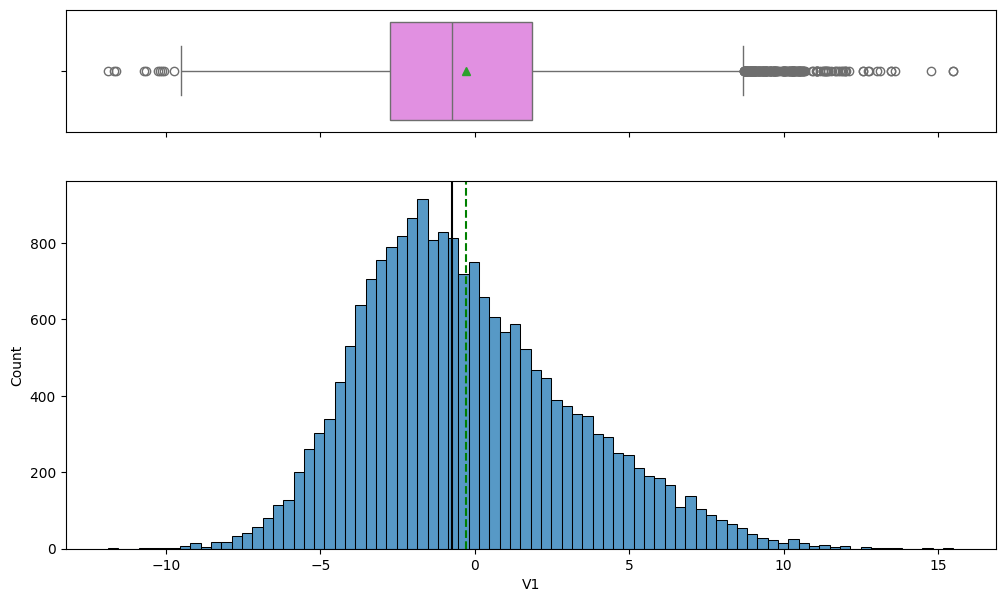

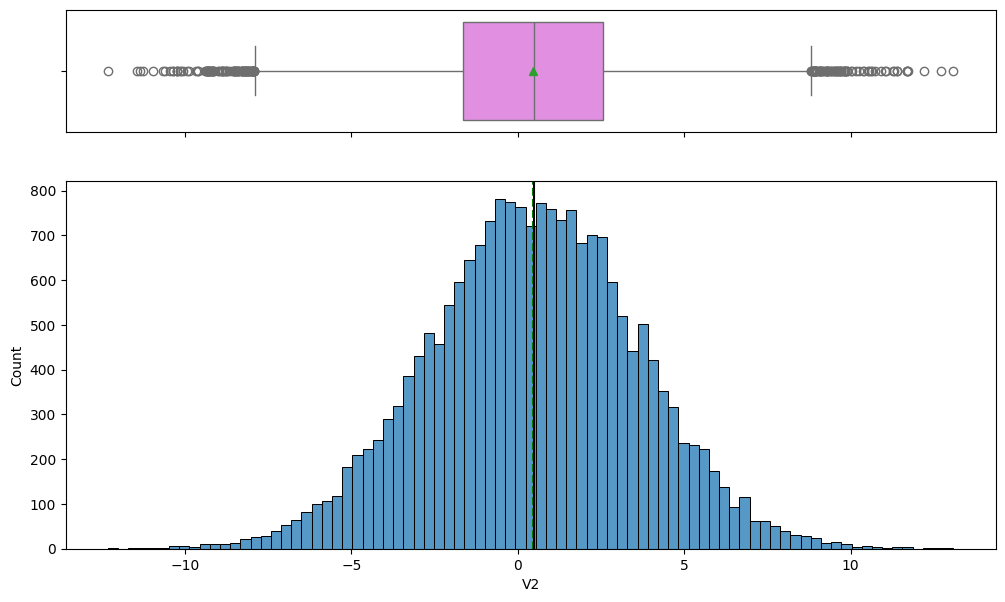

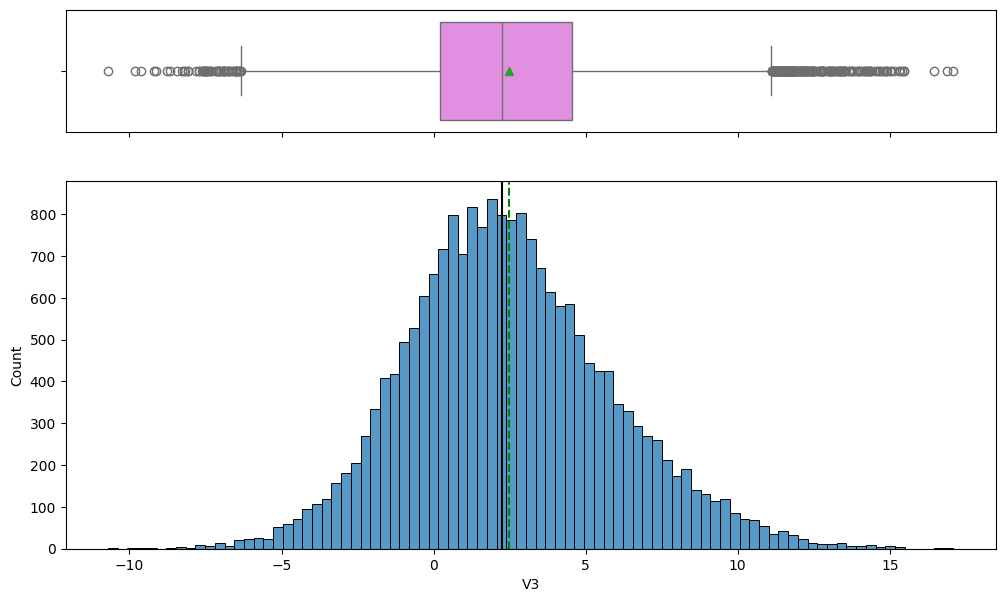

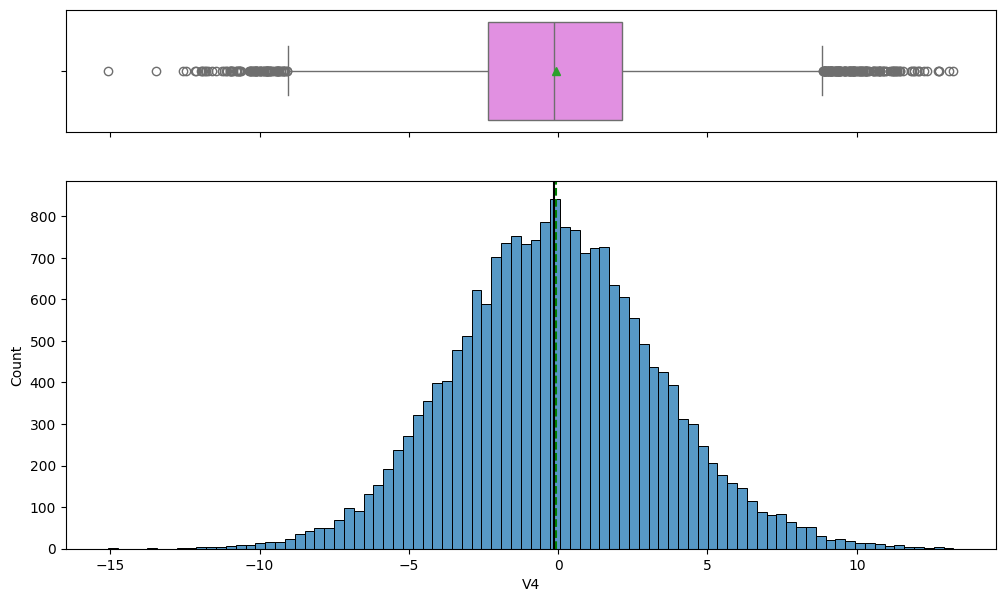

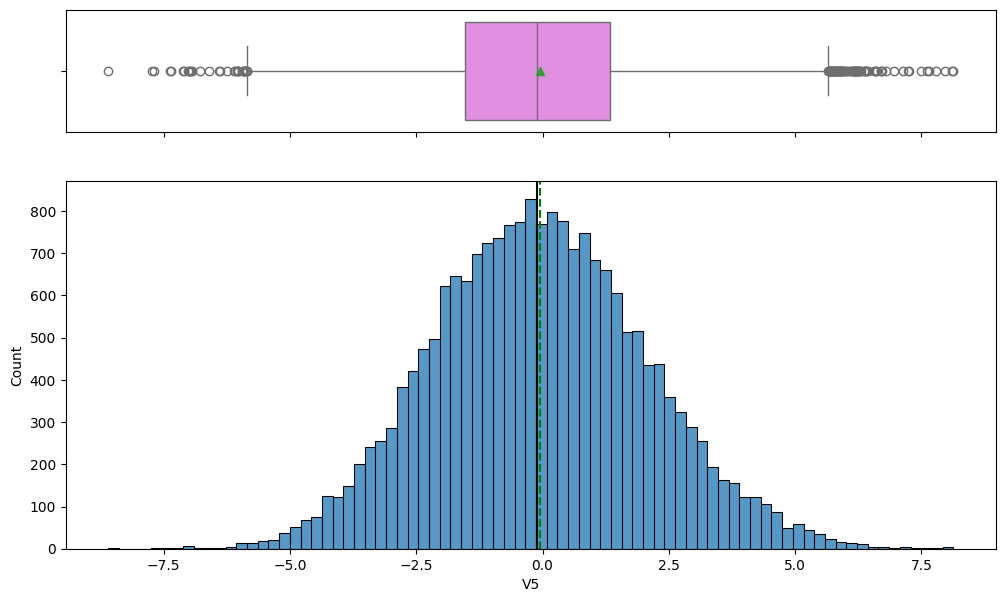

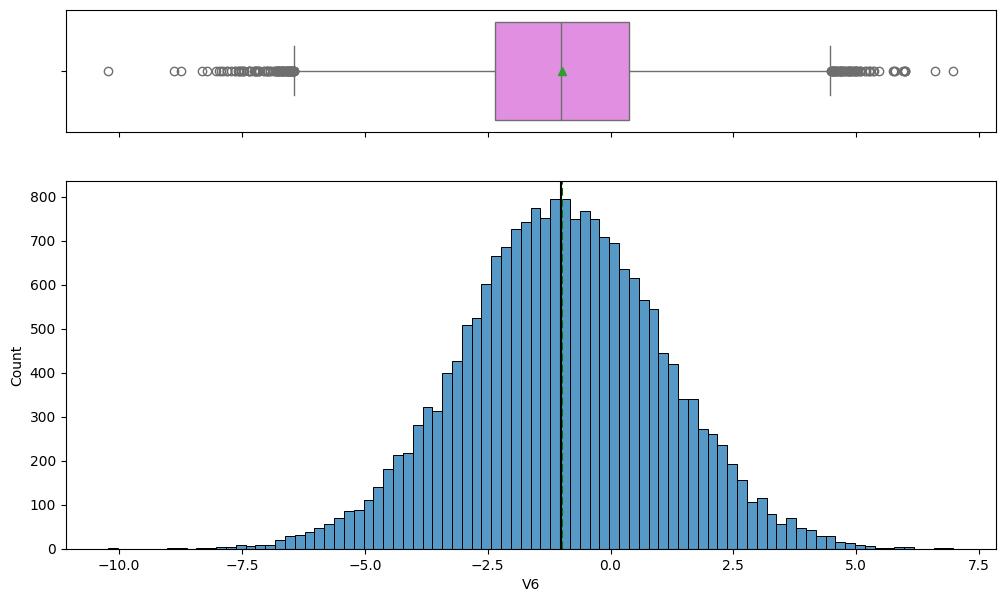

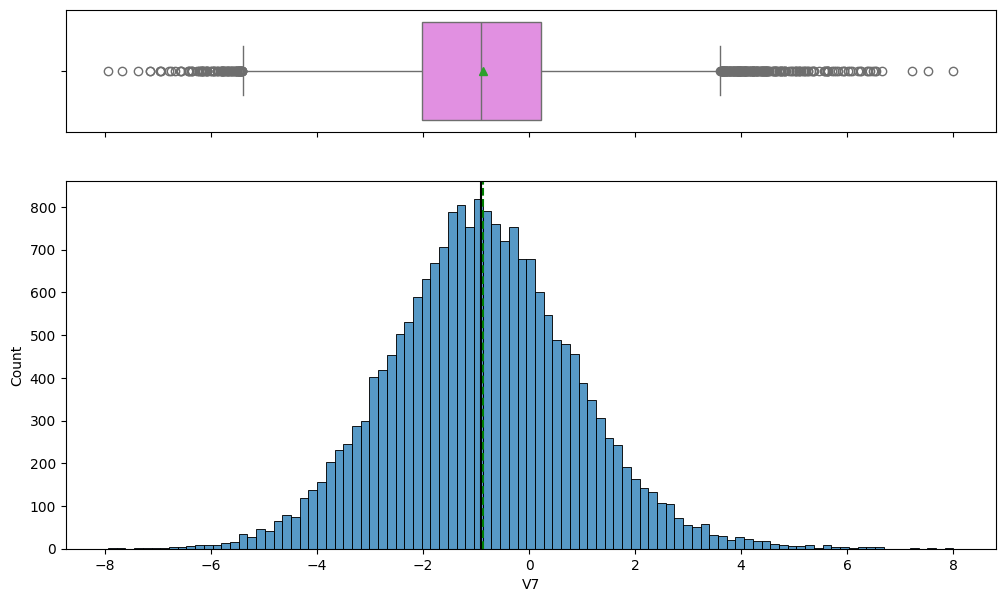

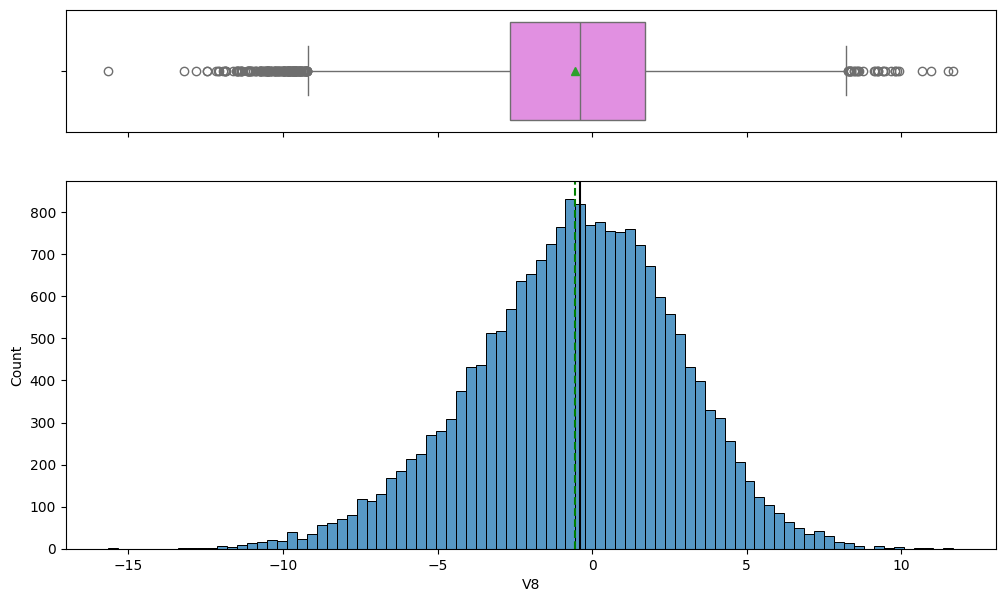

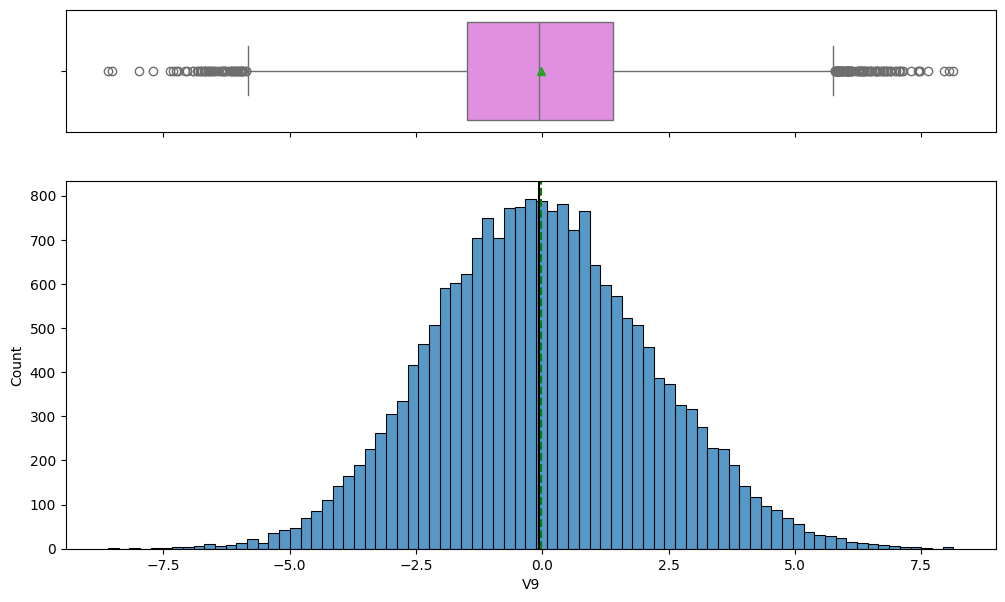

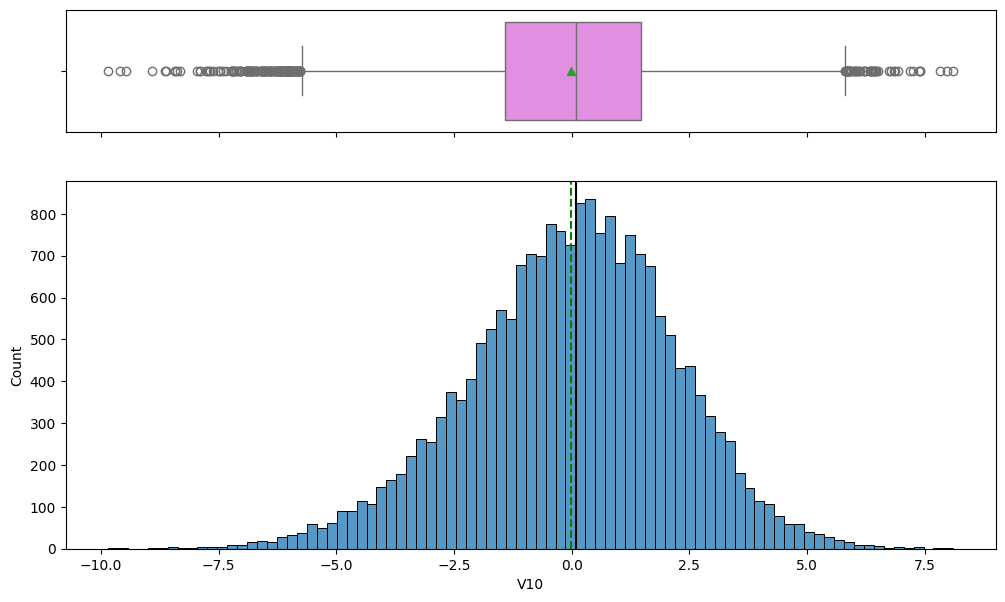

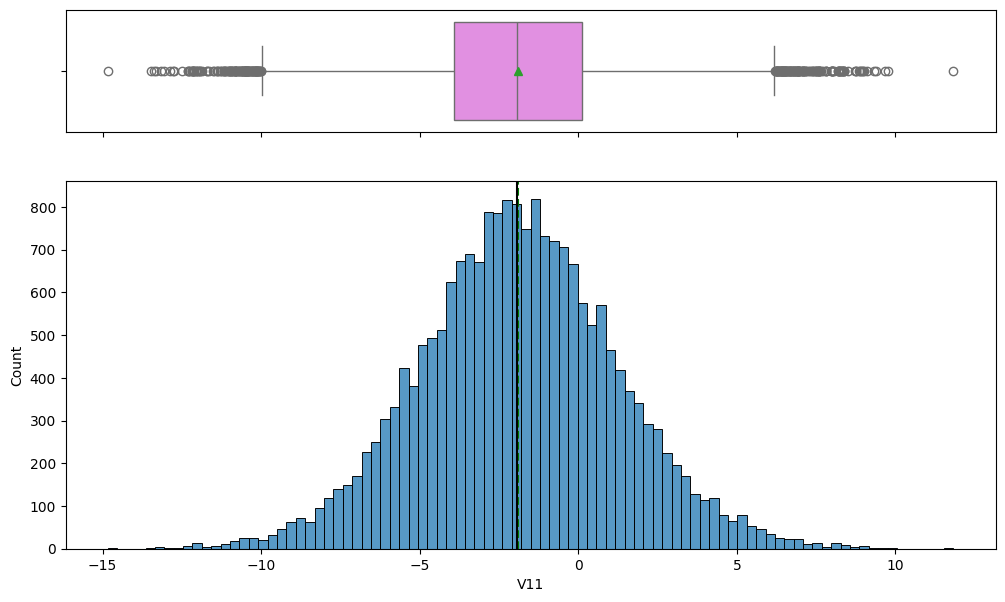

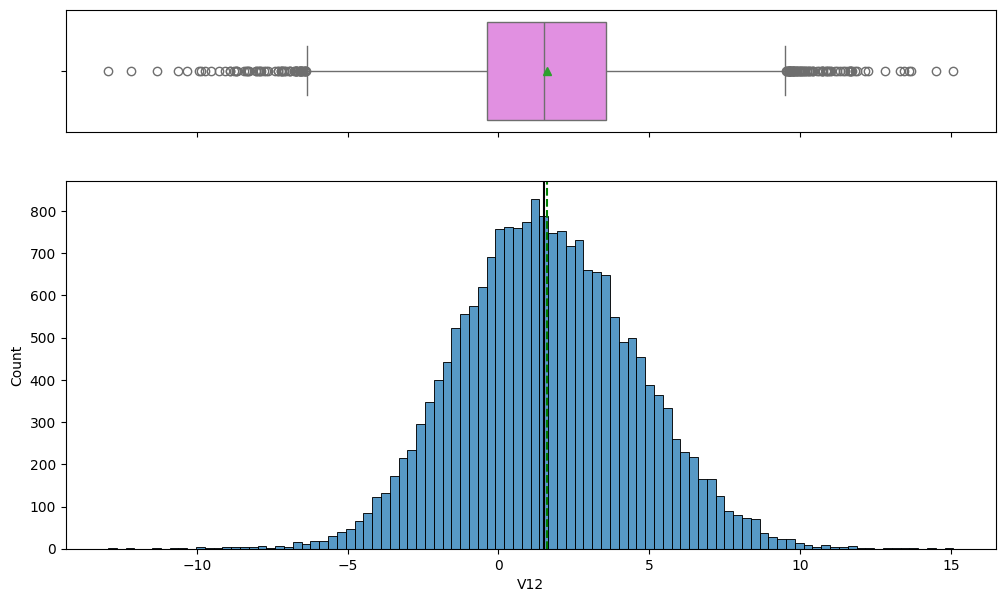

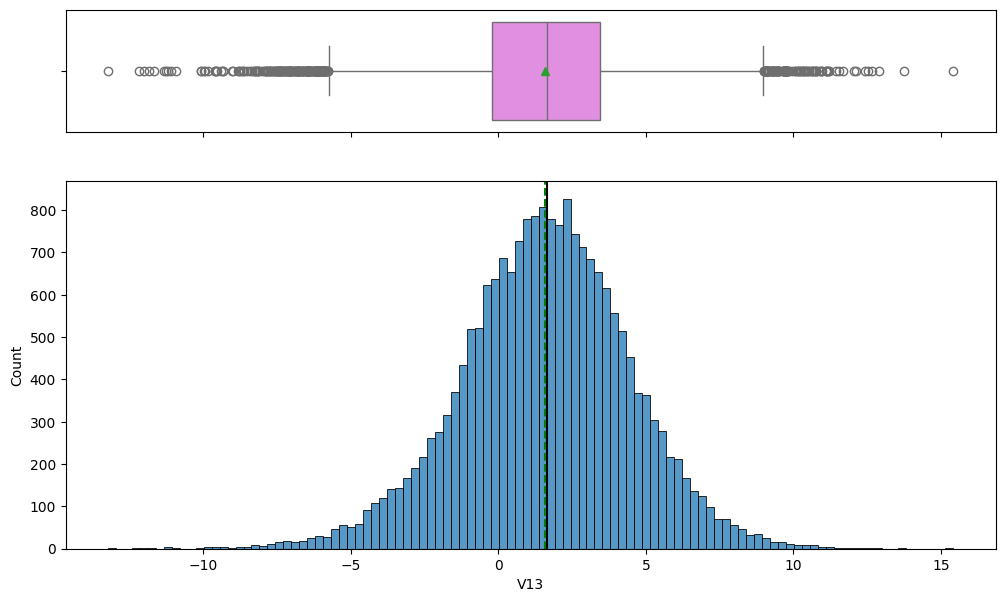

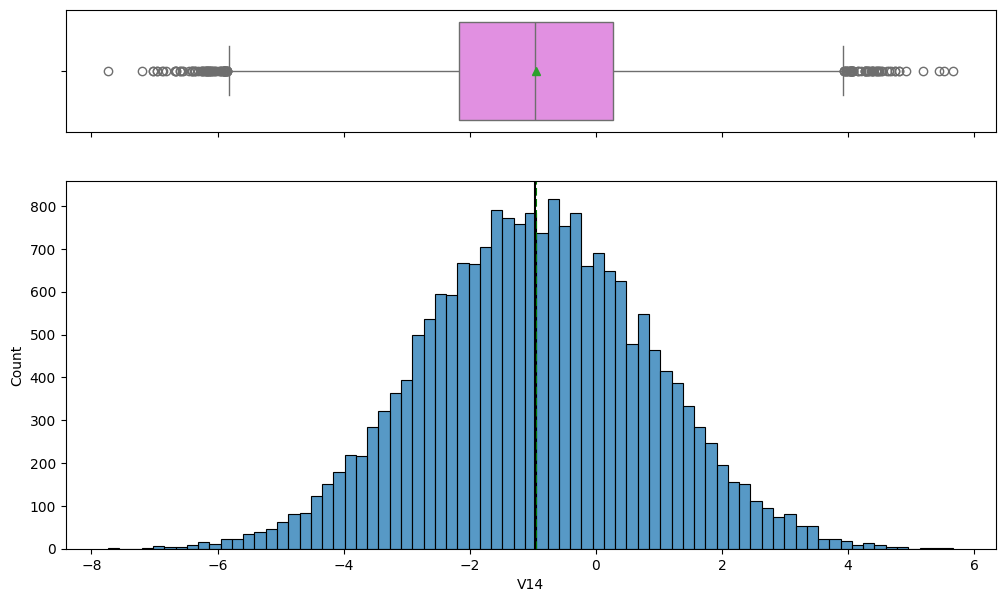

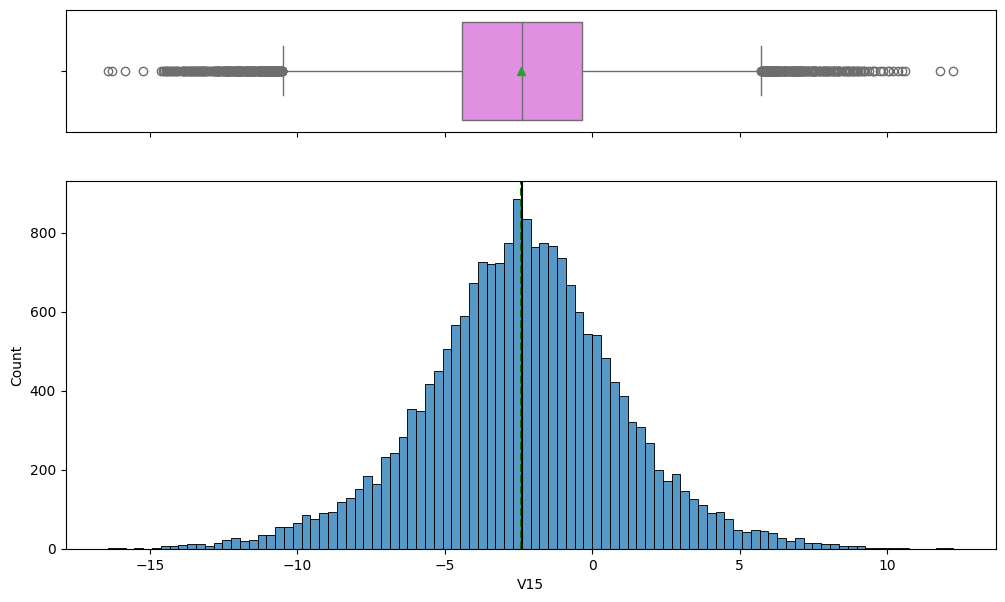

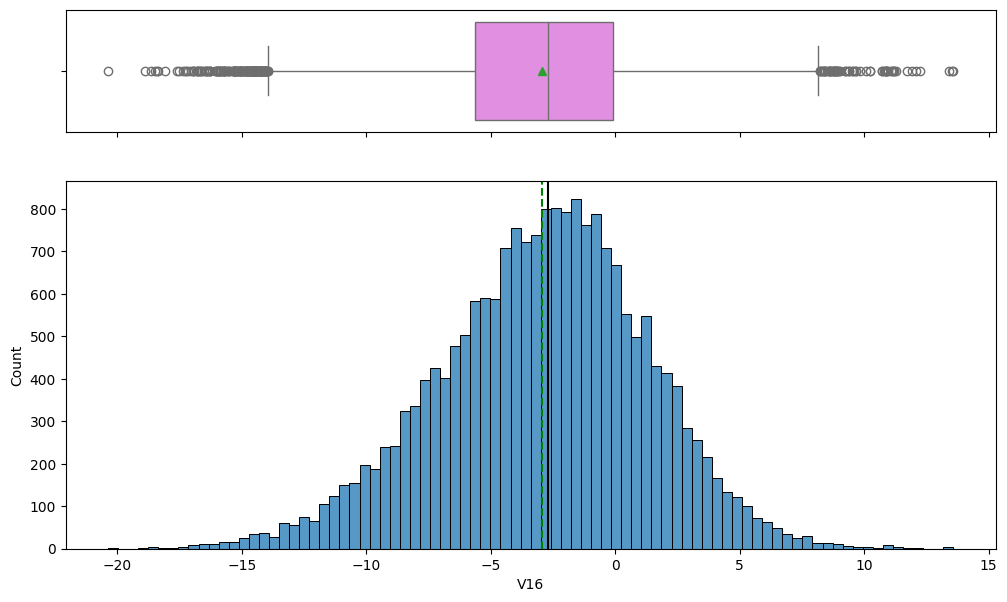

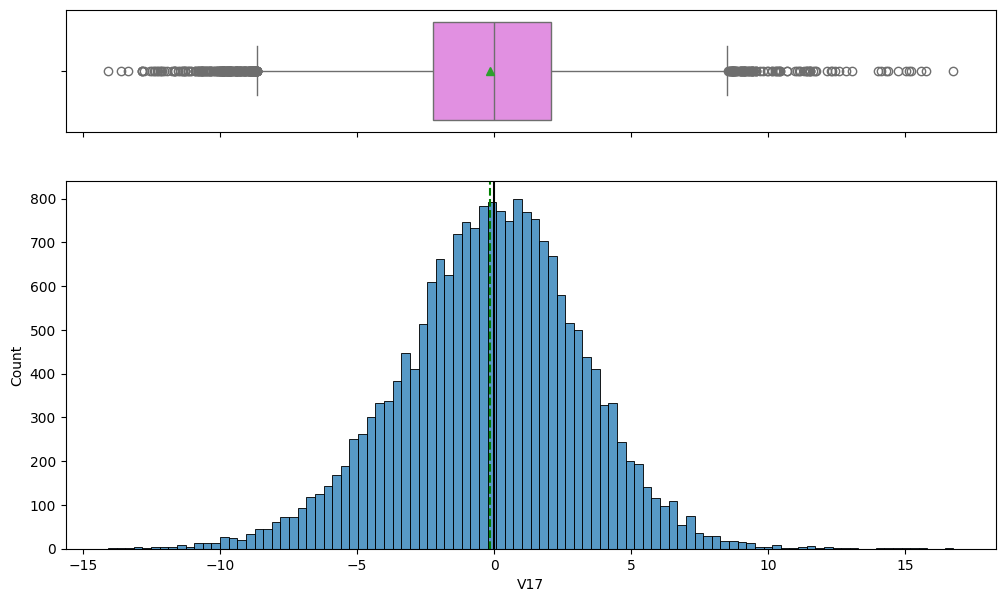

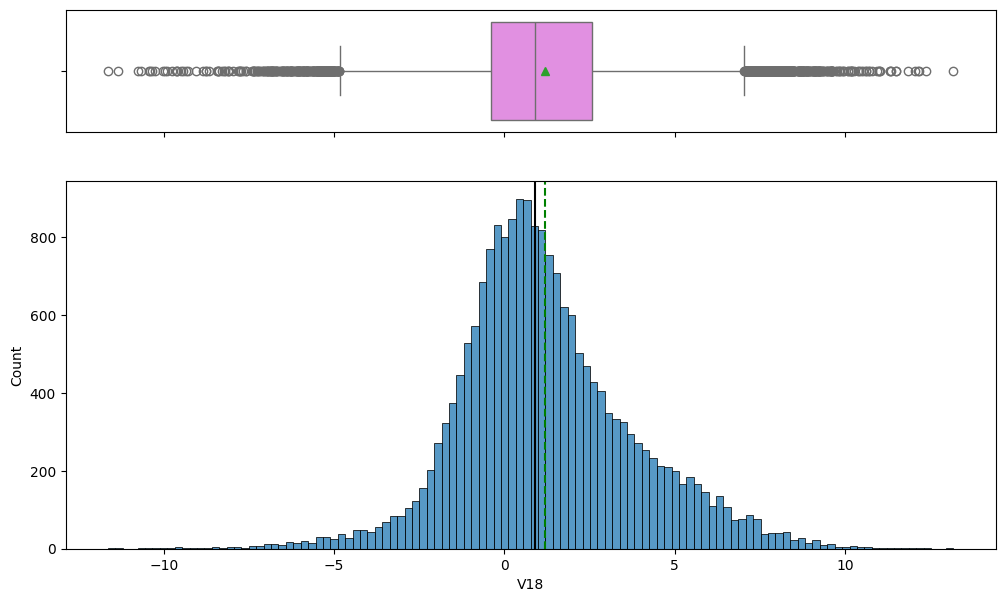

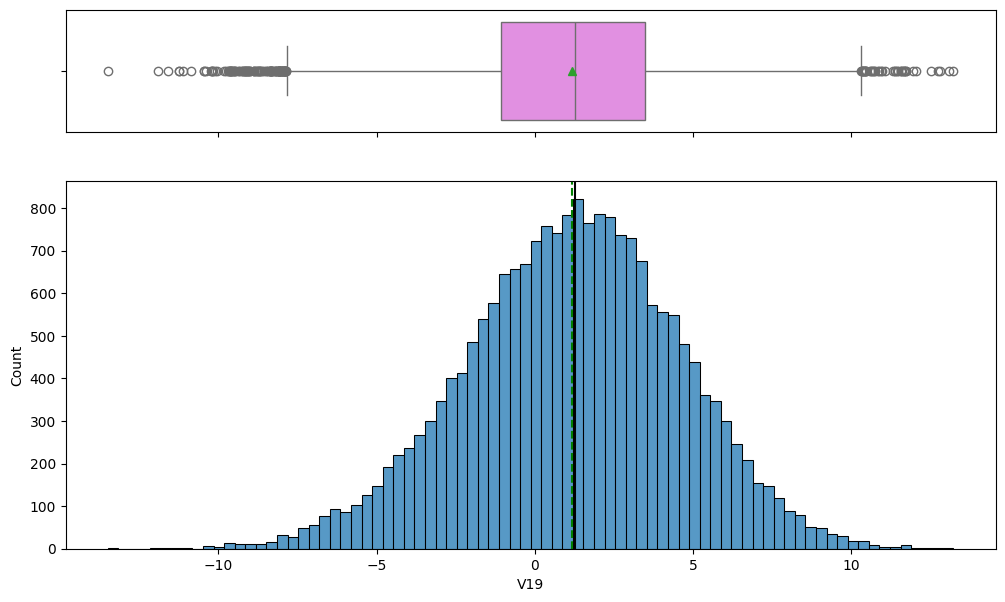

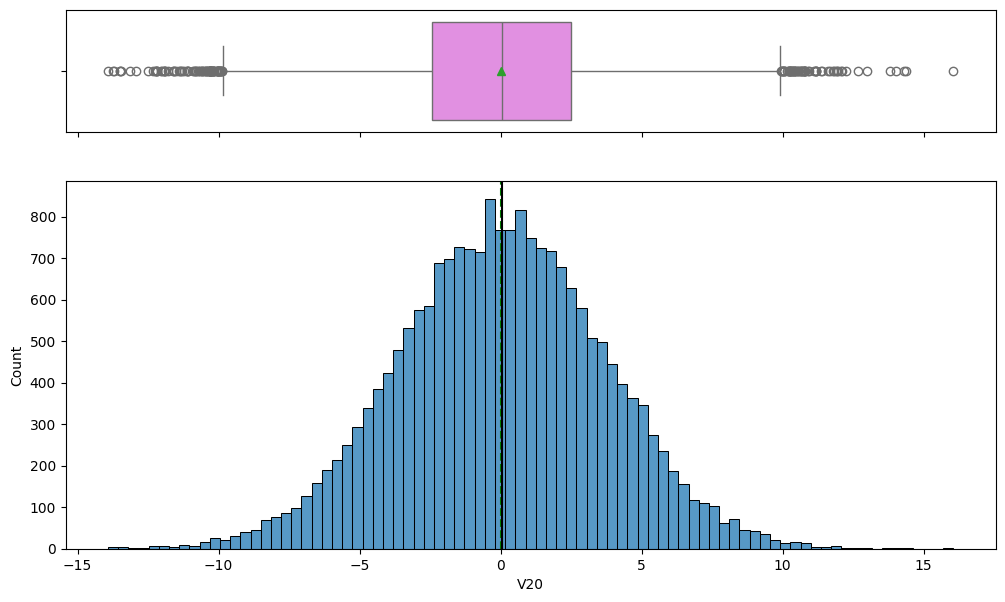

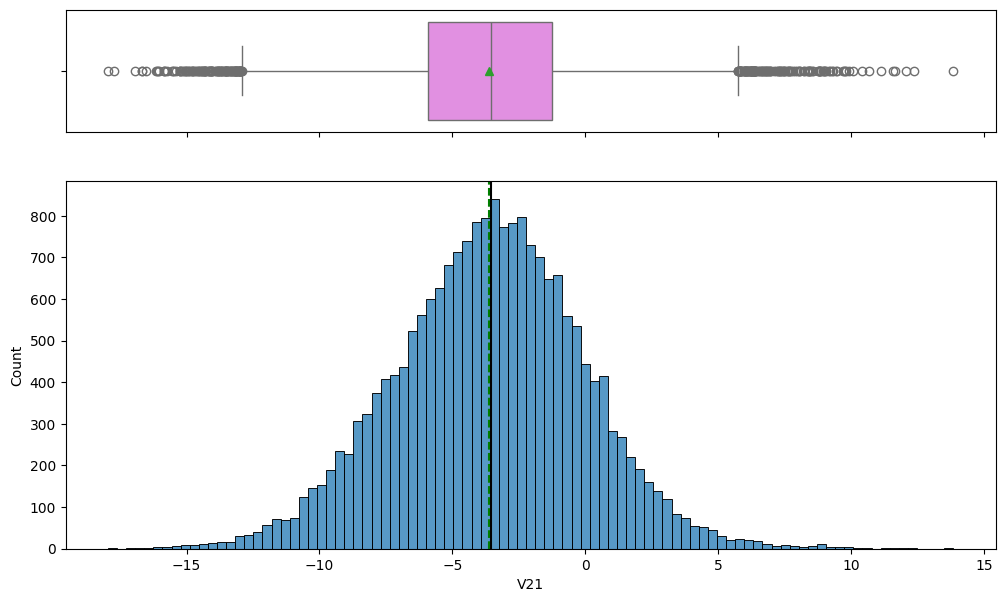

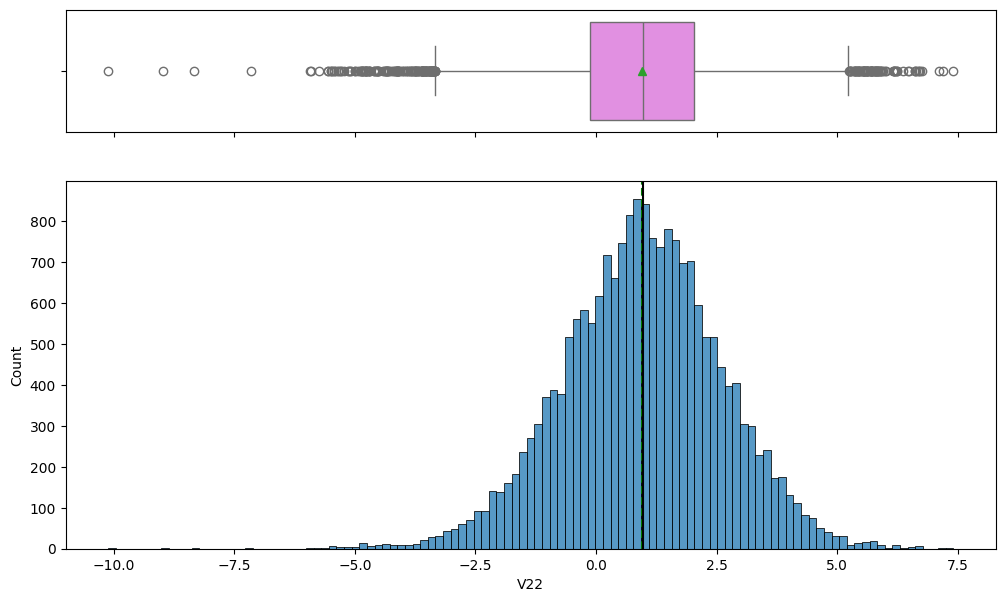

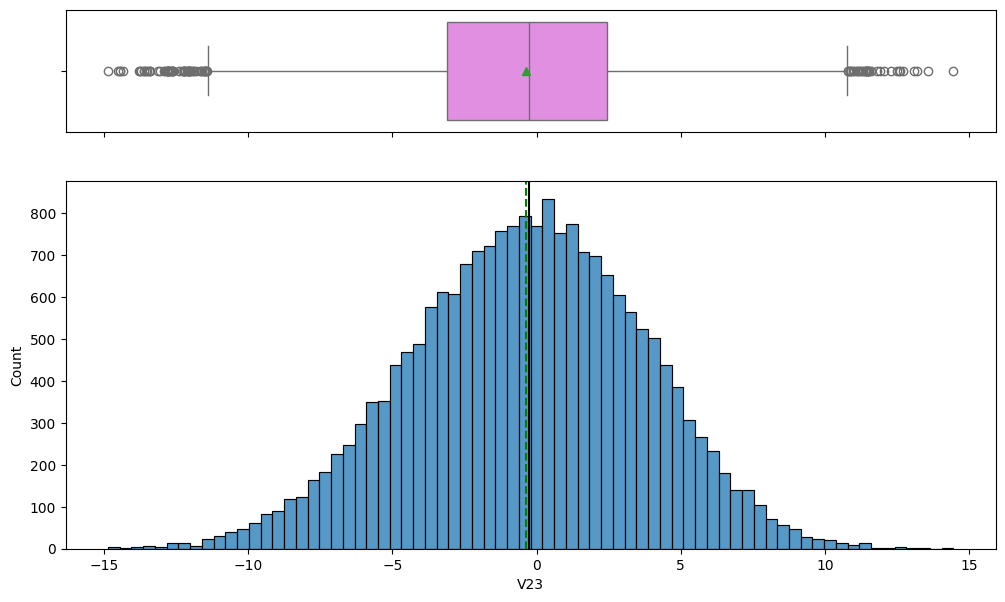

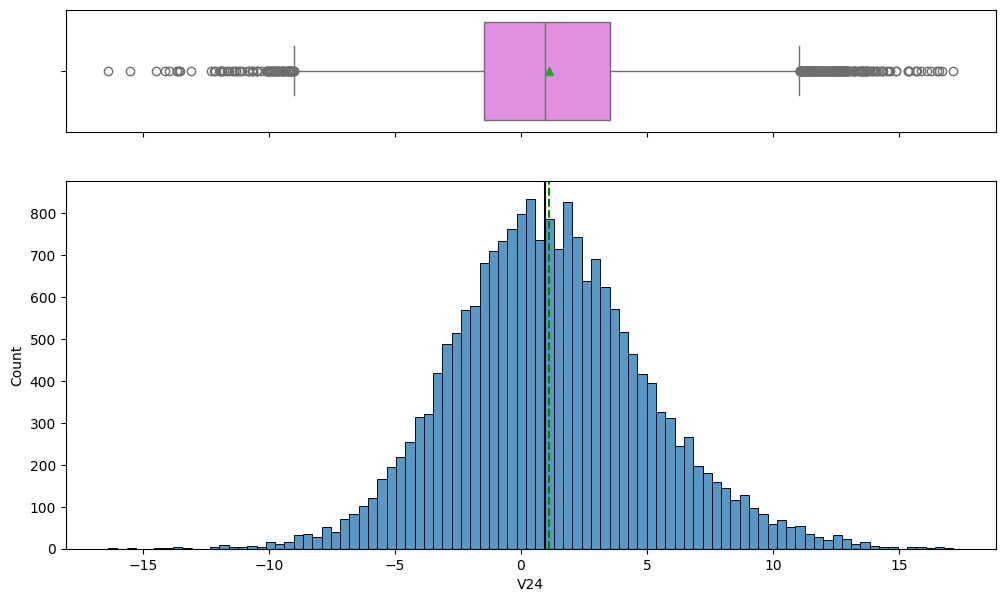

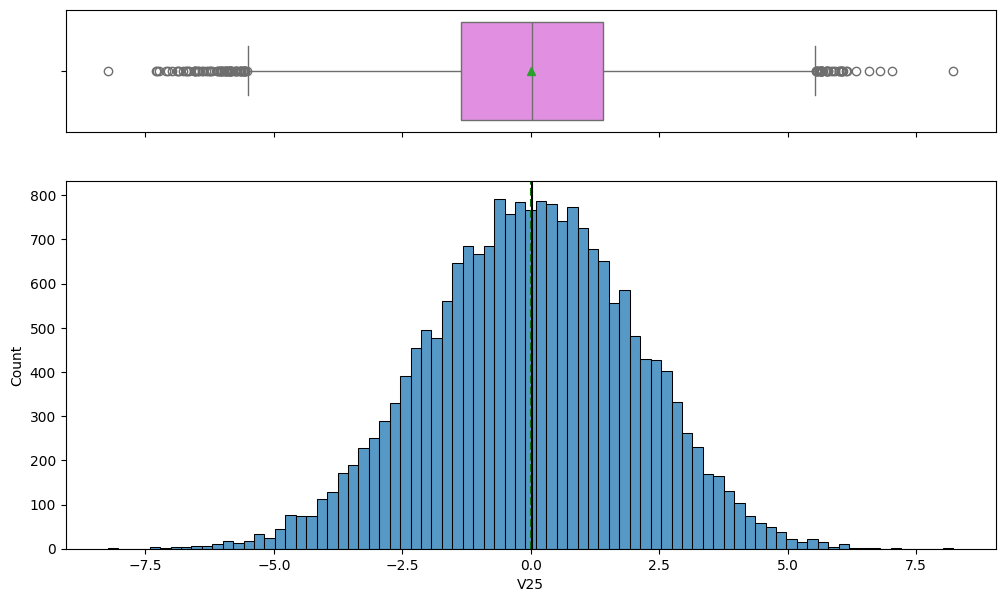

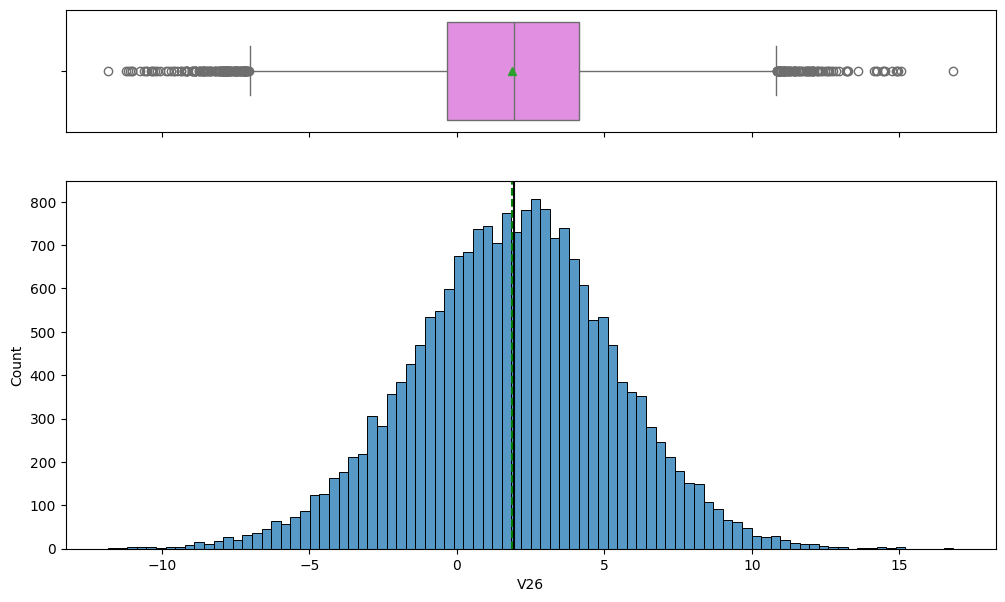

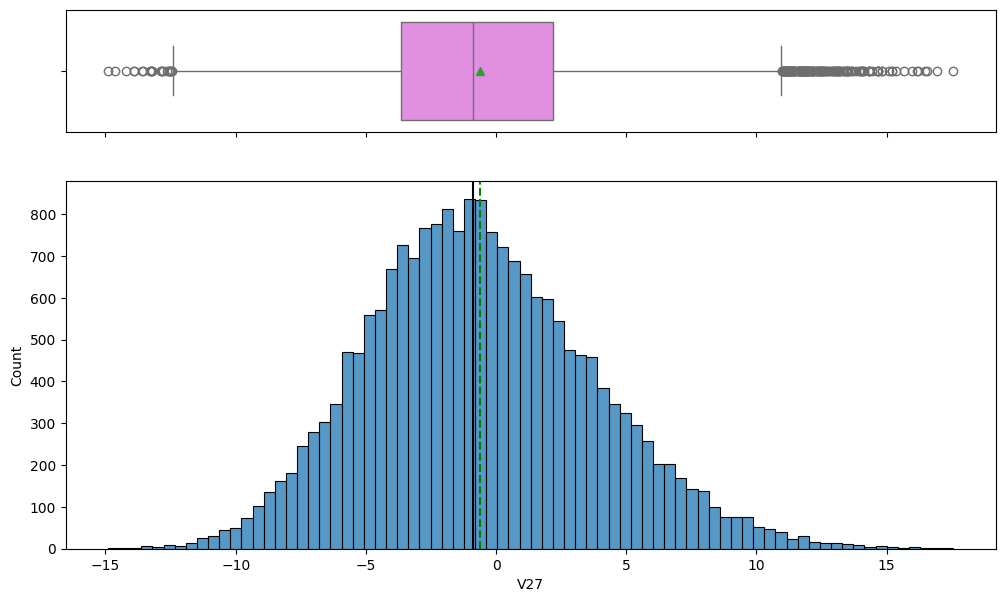

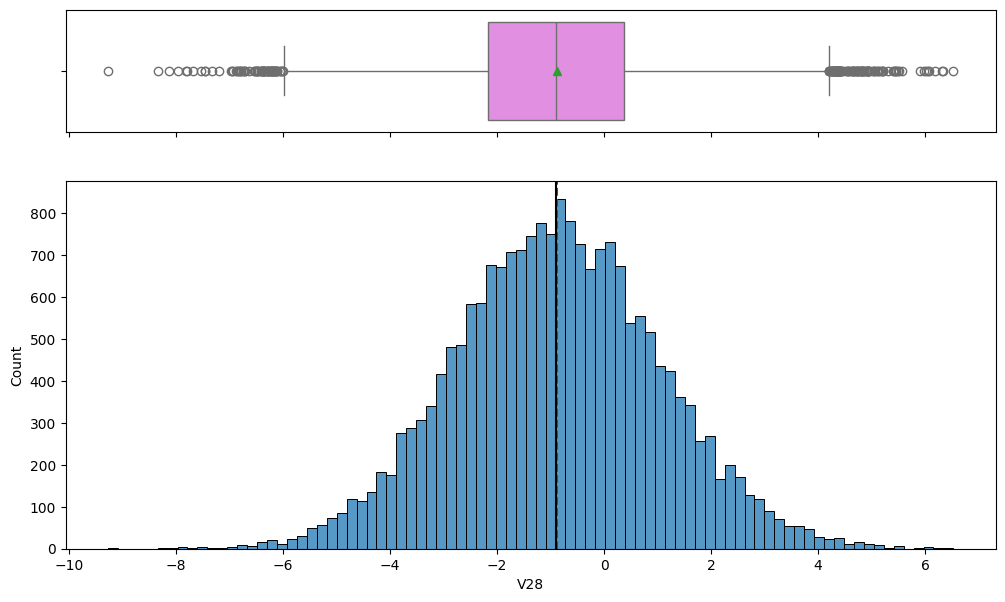

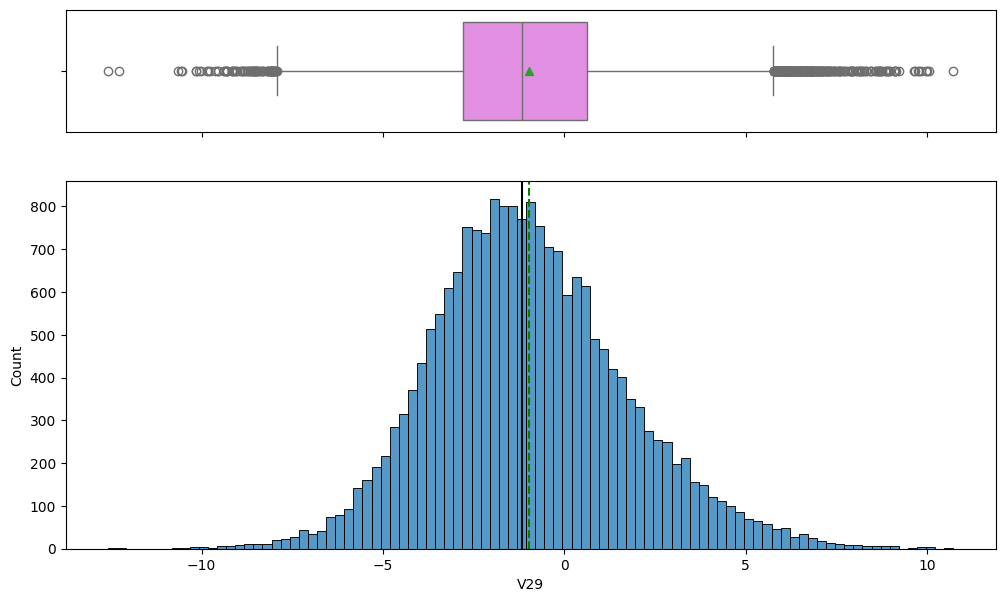

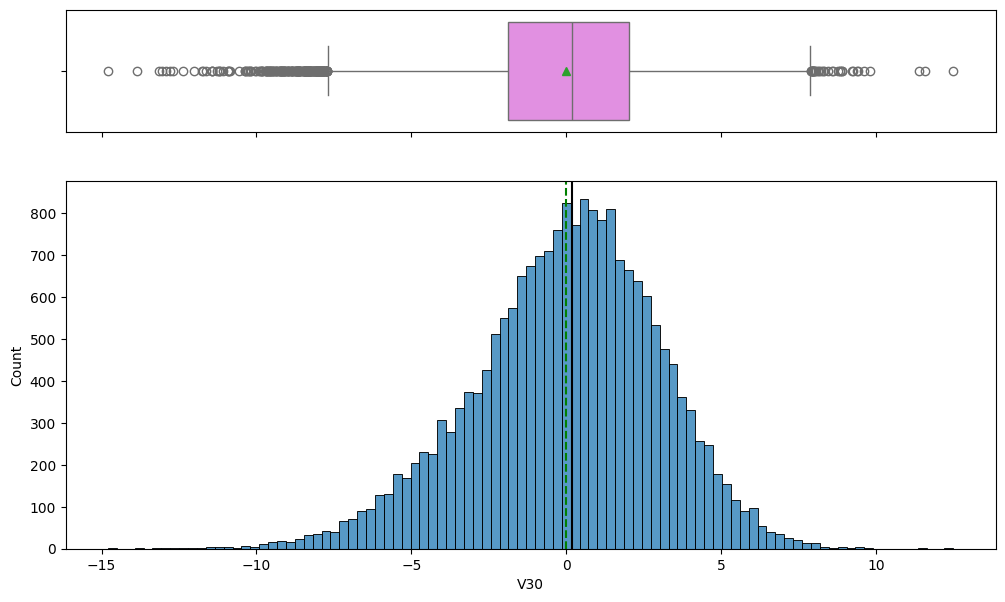

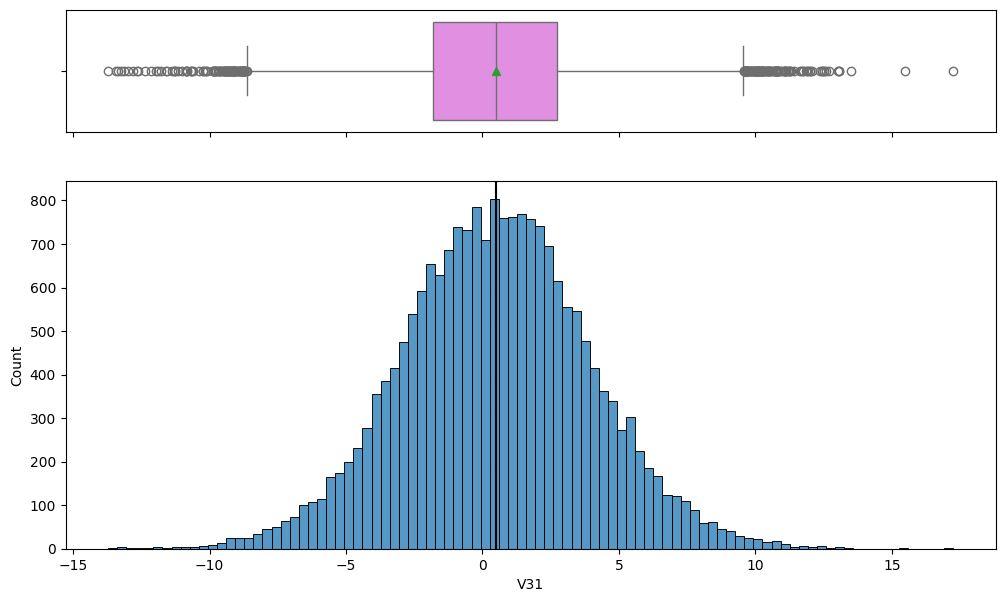

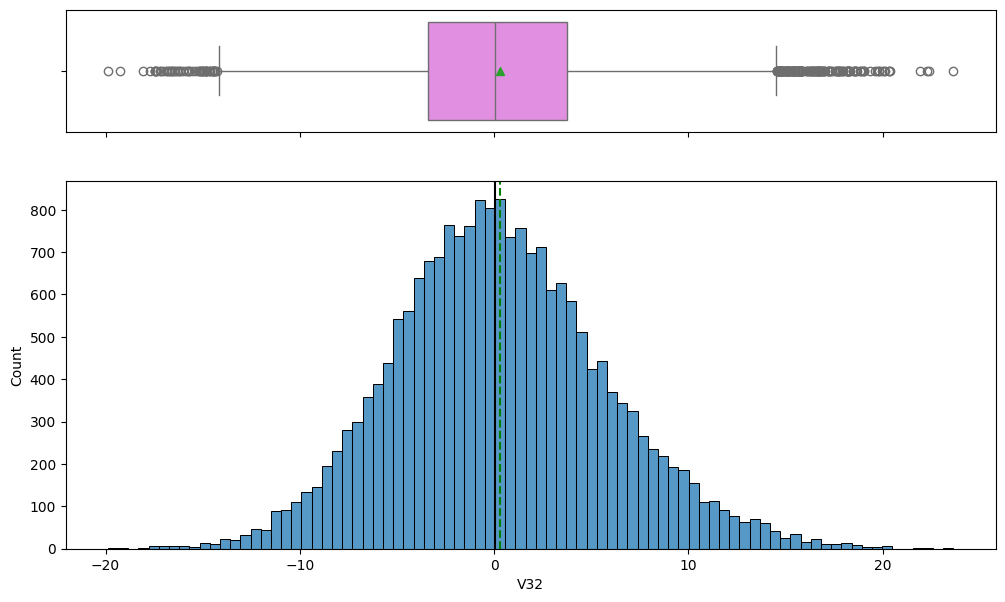

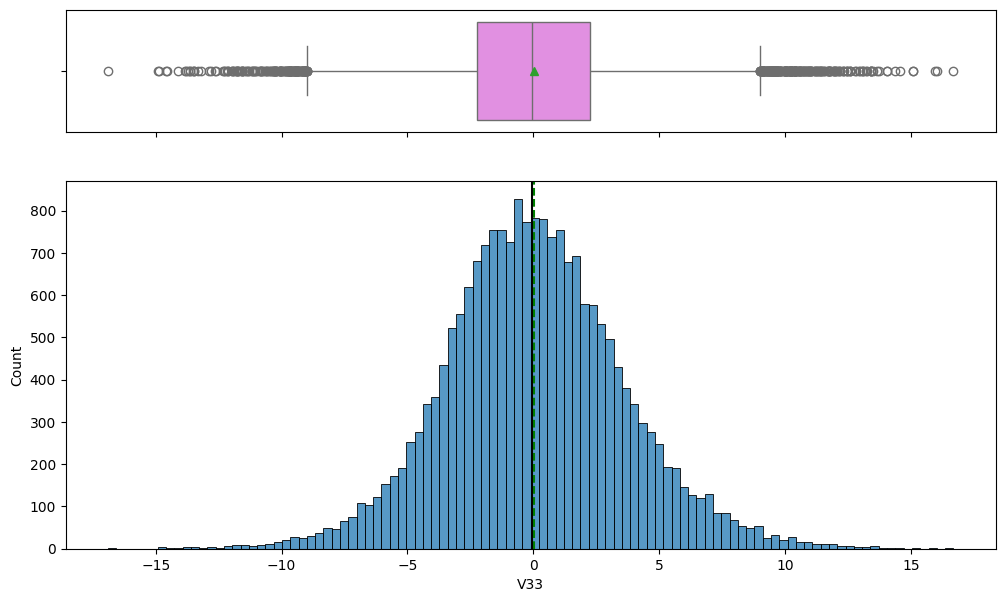

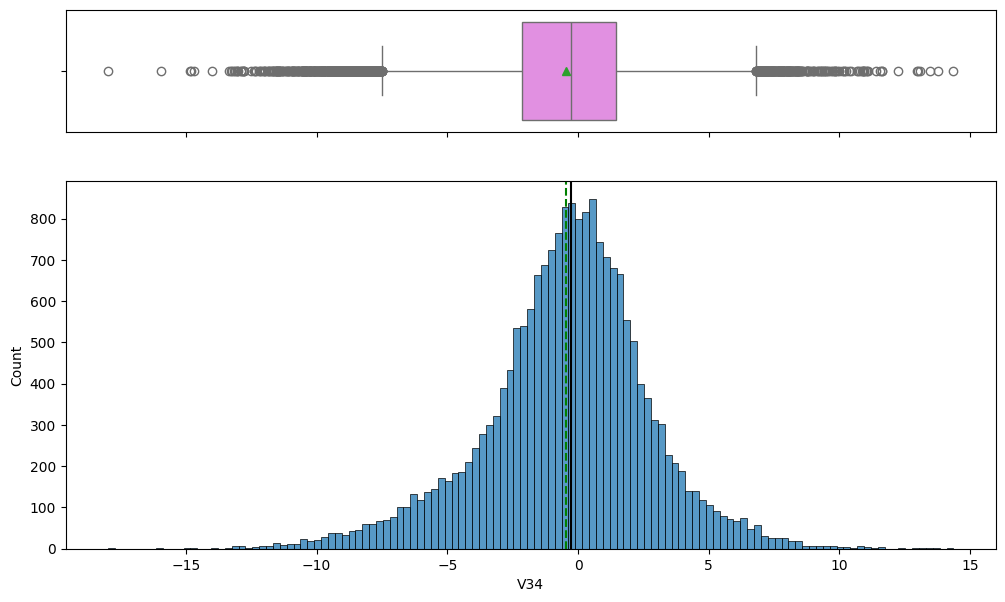

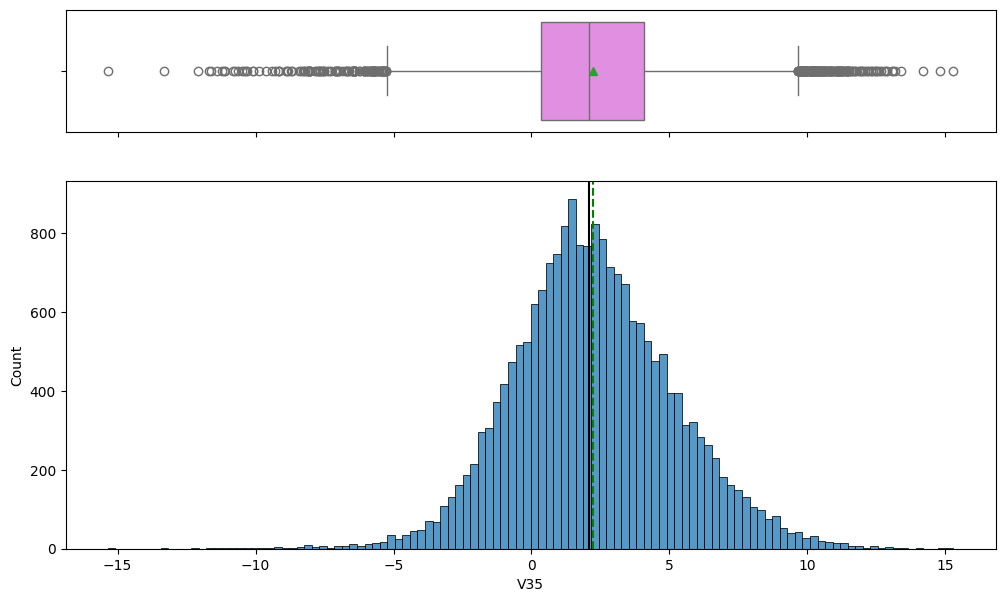

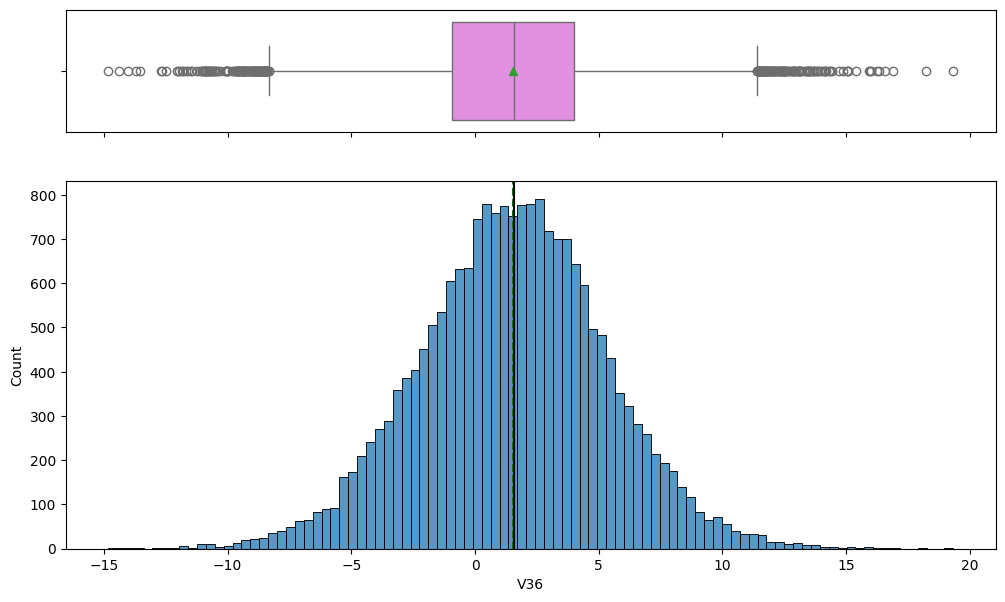

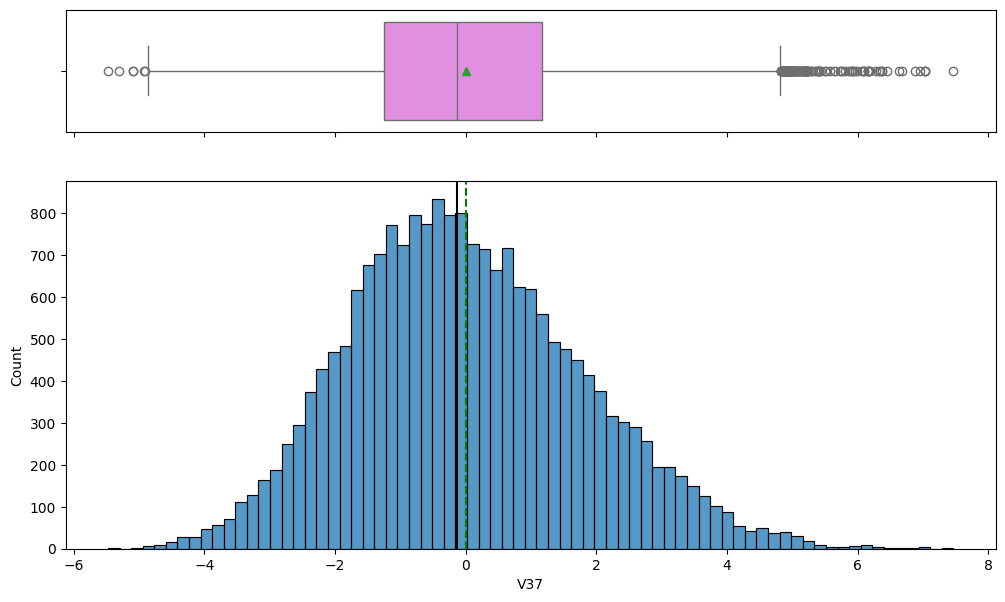

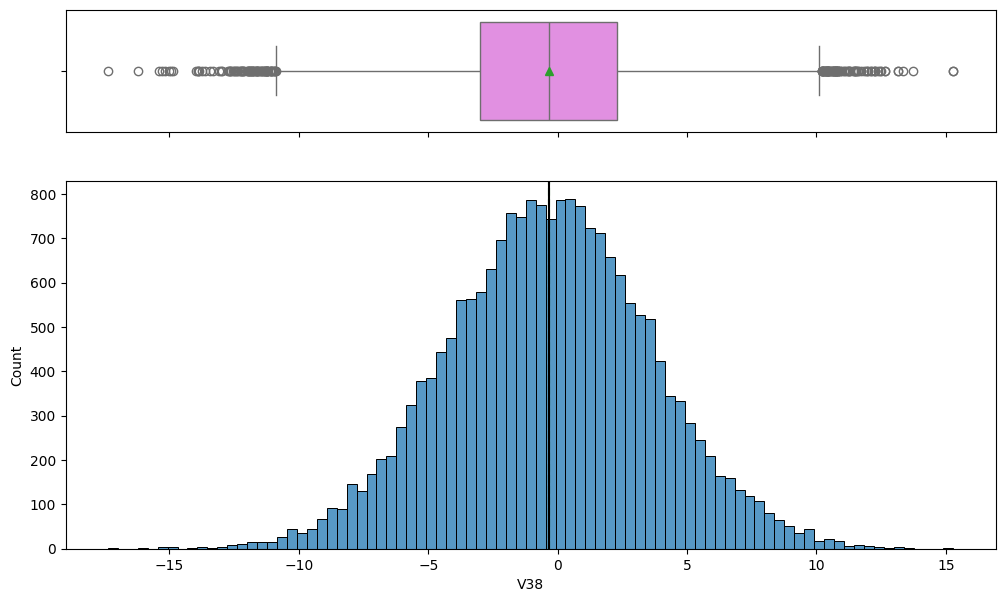

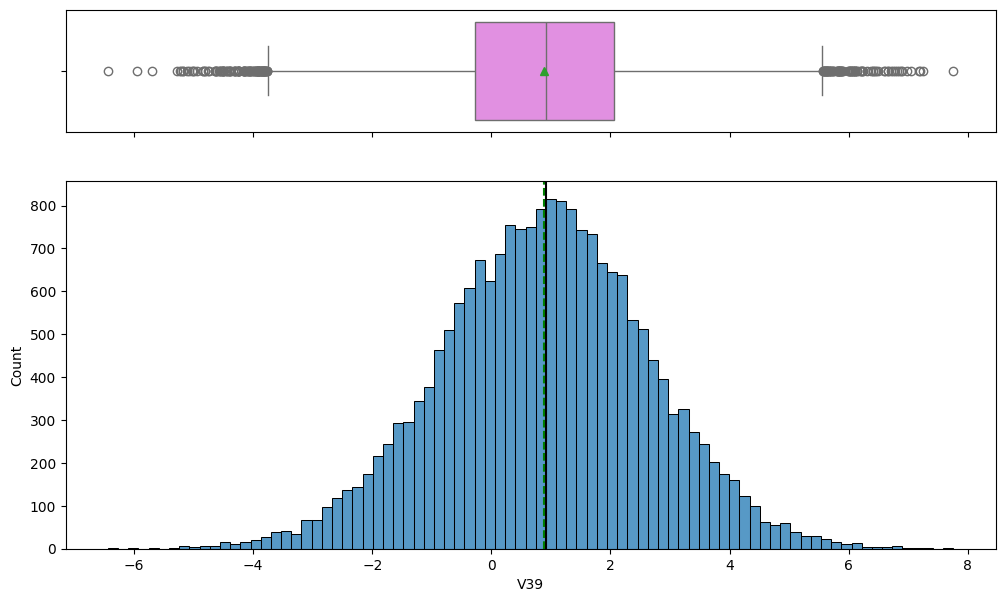

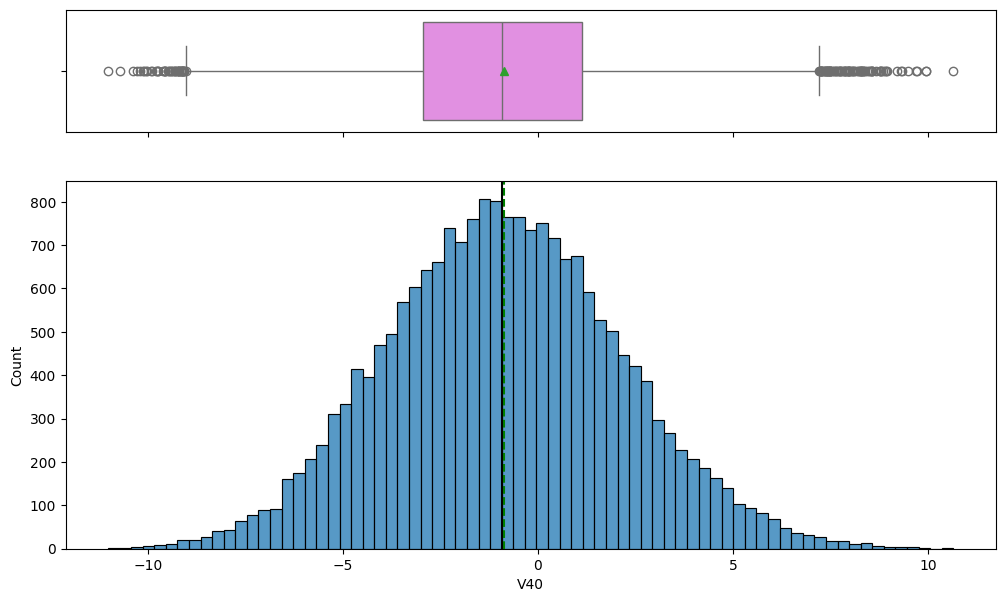

In [ ]:
for feature in data.columns[:-1]:
    histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None)

### Checking the distribution of Target Variable

In [ ]:
# For train data
data["Target"].value_counts(1)

,proportion
Target,
0.0,0.9445
1.0,0.0555


In [ ]:
# For test data
data_test["Target"].value_counts(1)

,proportion
Target,
0.0,0.9436
1.0,0.0564


## Bivariate Analysis

### Correlation Check

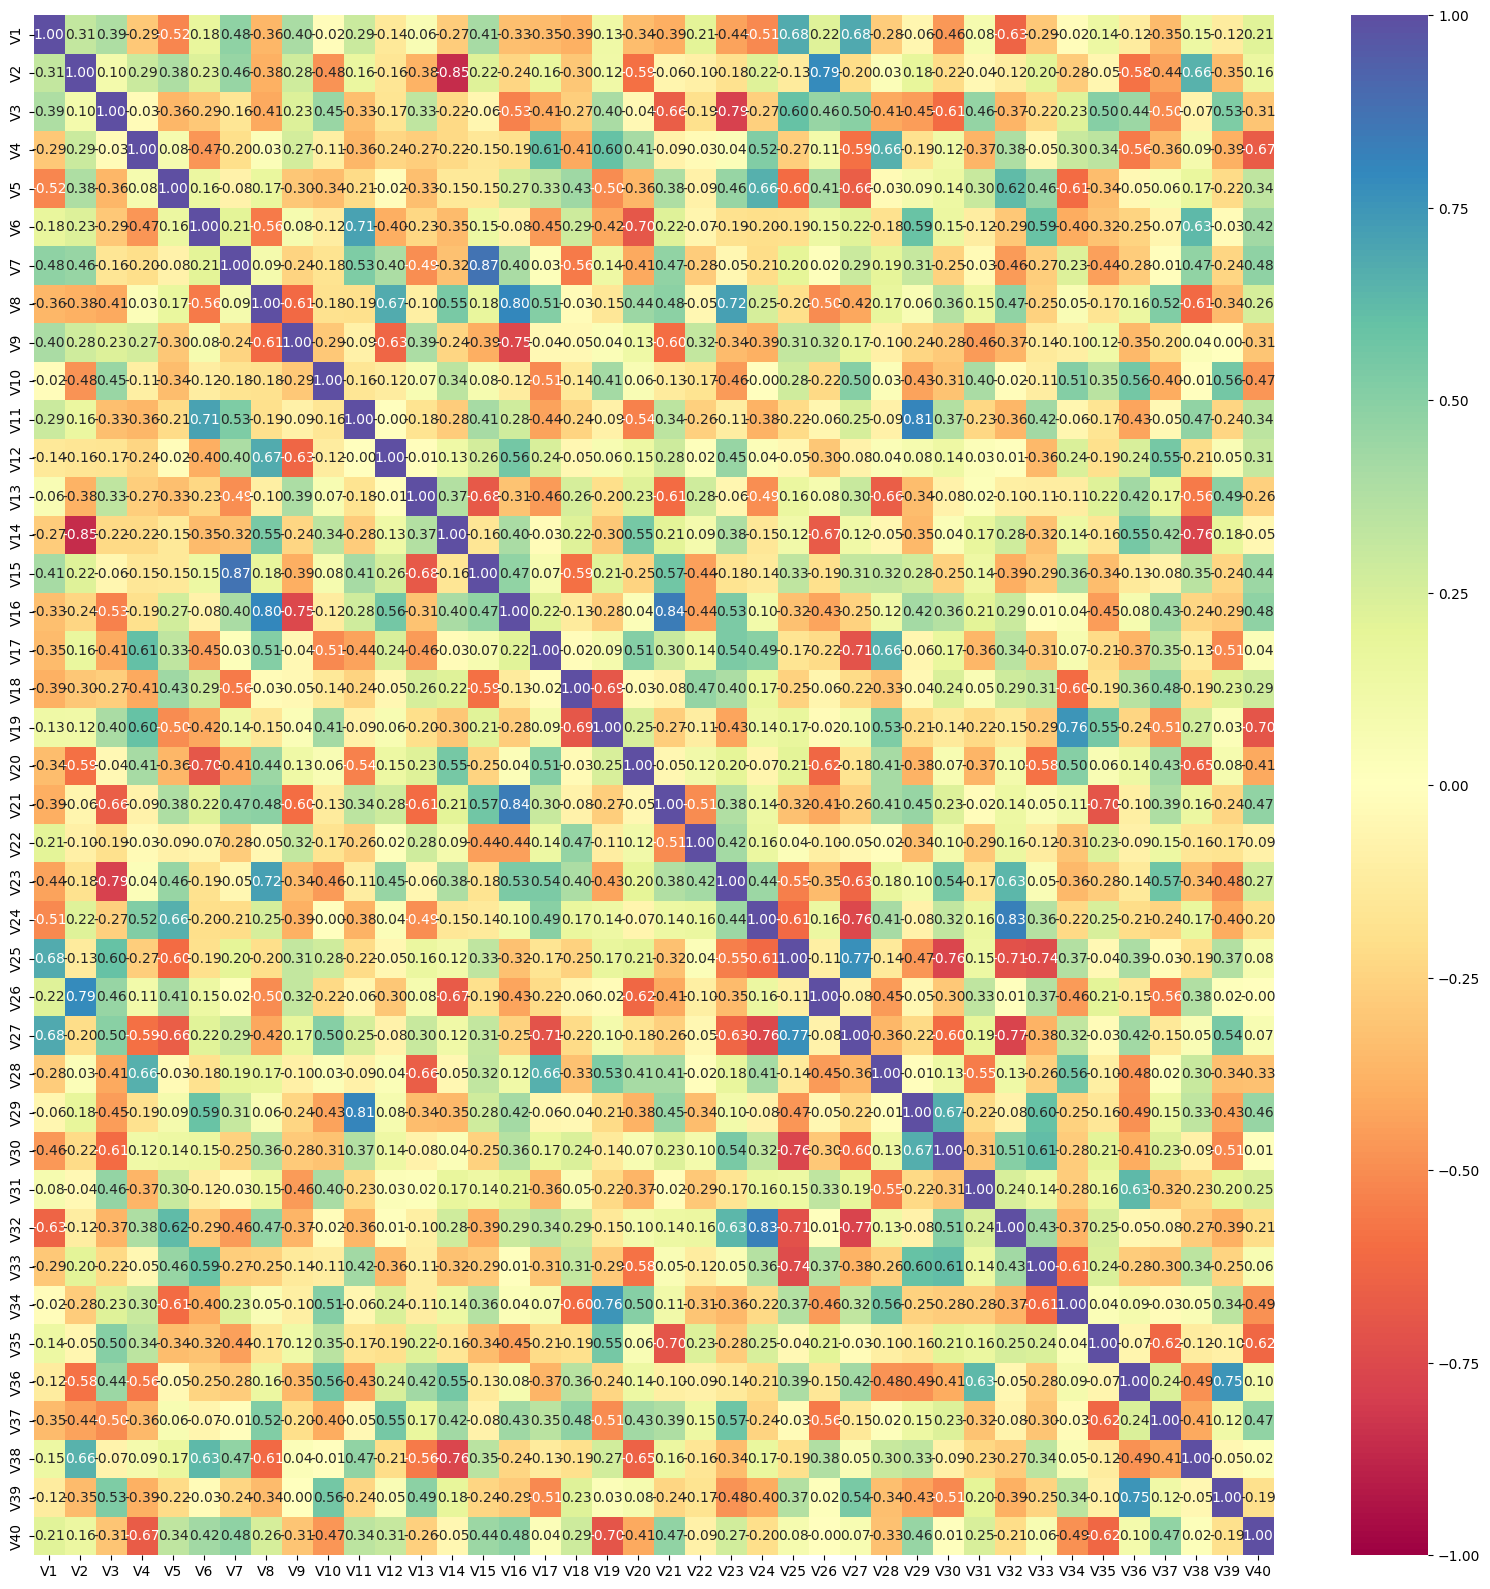

In [ ]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()
cols_list.remove("Target")

plt.figure(figsize=(20, 20))
sns.heatmap(
    df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

In [ ]:
correlation_matrix = data[cols_list].corr()

# Unstack the correlation matrix and drop self-correlations
correlation_pairs = correlation_matrix.unstack()

# Filter out self-correlations (where feature1 == feature2) and absolute correlations less than 1
filtered_correlation_pairs = correlation_pairs[correlation_pairs.index.get_level_values(0) != correlation_pairs.index.get_level_values(1)]

# Sort the correlations by absolute value in descending order
sorted_correlation_pairs = filtered_correlation_pairs.abs().sort_values(ascending=False)

# Display the top 10 highest correlations
print("Top 12 highest correlations (absolute values):")
print(sorted_correlation_pairs.head(12))

Top 12 highest correlations (absolute values):
V15  V7     0.867871
V7   V15    0.867871
V2   V14    0.853530
V14  V2     0.853530
V21  V16    0.836527
V16  V21    0.836527
V24  V32    0.825119
V32  V24    0.825119
V11  V29    0.811228
V29  V11    0.811228
V8   V16    0.802505
V16  V8     0.802505
dtype: float64


# **Data Preprocessing**

In [ ]:
# Dividing train data into X and y
X = data.drop(columns = ["Target"] , axis=1)
y = data["Target"]

### Missing Value Imputation

* There were few missing values in V1 and V2, along with few NaN values in X and Y, I will impute them using the median.

In [ ]:
imputer = SimpleImputer(strategy="median")

In [ ]:
# fill NaN values in X and y with its median
X = X.fillna(X.median())
y = y.fillna(y.median())

In [ ]:
# Splitting data into training and validation set:

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

In [ ]:
# Checking the number of rows and columns in the X_train data
X_train.shape

(16000, 40)

In [ ]:
# Checking the number of rows and columns in the X_val data
X_val.shape

(4000, 40)

In [ ]:
# Dividing test data into X_test and y_test
X_test = data_test.drop(columns = ['Target'] , axis= 1) # Complete the code to remove the target column
y_test = data_test["Target"] # Complete the code to select the target column

In [ ]:
X_test.shape

(5000, 40)

In [ ]:
# Checking that no column has missing values in train or test sets
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     5
V2     6
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22

In [ ]:
y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

# **Model Building**

## Model Evaluation Criterion

### Primary Metric: Recall

The nature of predictions made by the classification model will translate as follows:

* True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
* False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
* False positives (FP) are detections where there is no failure. These will result in inspection costs.

Which case is more important?
* Failing to detect real failures (False negatives) is critical, as replacement costs are the most expensive outcome for ReneWind.

How to reduce this loss?
* I'll judge the model on recall since inspection and repair costs are less cost prohibitive than actual equipment replacement. I'll tolerate a small number of False Postives (detections with no real failures) from the model if it means fewer False Negatives when the model does not detect real failures.

In [ ]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors) > threshold
    # pred_temp = model.predict(predictors) > threshold
    # # rounding off the above values to get classes
    # pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='macro')  # to compute Recall
    precision = precision_score(target, pred, average='macro')  # to compute Precision
    f1 = f1_score(target, pred, average='macro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,}, index = [0]
    )

    return df_perf

## Initial Model Building (Model 0)

I'll build this baseline neural network model using a simple architecture:

* Input Layer: The input shape is determined by the number of features in the training data, X_train​.
* Hidden Layer: I'm using one hidden layer with 7 neurors using the ReLU activation function.
* Output Layer: One Dense layer with 1 unit and a sigmoid activation to handle binary classification.
* Loss Function: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

Optimizer: We use Stochastic Gradient Descent (SGD) as the optimizer to adjust the network's weights during training.

Metrics: The model is evaluated using the Recall metric.

The model is trained for 50 epochs, with a batch size of 40.

In [ ]:
# defining the batch size and # epochs upfront as we'll be using the same values for all models
epochs = 50
batch_size = 40

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
model_0 = Sequential()
model_0.add(Dense(7,activation="relu",input_dim=X_train.shape[1]))
model_0.add(Dense(1,activation="sigmoid")) # Complete the code to define the number of neurons in the output layer

In [ ]:
model_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │           287 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295 (1.15 KB)

 Trainable params: 295 (1.15 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.SGD()   # defining SGD as the optimizer to be used
model_0.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['Recall'])

In [ ]:
start = time.time()
history = model_0.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - Recall: 0.3818 - loss: 0.1999 - val_Recall: 0.5721 - val_loss: 0.1122
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.5822 - loss: 0.1029 - val_Recall: 0.6667 - val_loss: 0.1002
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.6408 - loss: 0.0917 - val_Recall: 0.6802 - val_loss: 0.0937
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Recall: 0.6745 - loss: 0.0862 - val_Recall: 0.6712 - val_loss: 0.0901
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.6836 - loss: 0.0827 - val_Recall: 0.6847 - val_loss: 0.0876
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Recall: 0.7027 - loss: 0.0800 - val_Recall: 0.6802 - val_loss: 0.0854
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Recall: 0.7095 - loss: 0.0778 - val_Recall: 0.7117 - val_loss: 0.0834
Epoch 8/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Recall: 0.7185 - loss: 0.0758 - val_Recall: 0.7252 - val_loss: 0.0815
Epoch 9/

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  57.21757483482361


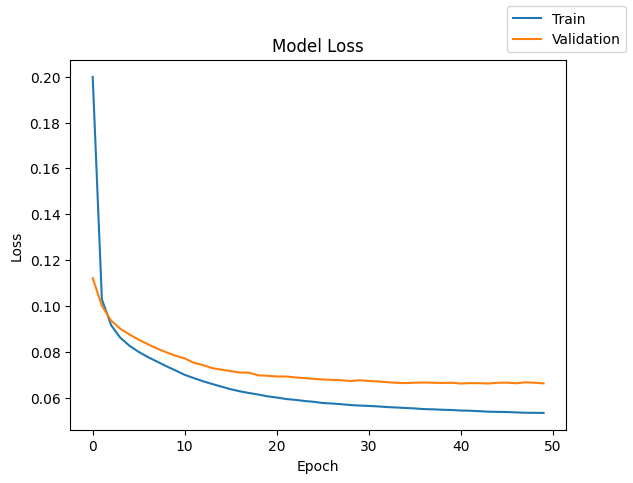

In [ ]:
plot(history,'loss')

In [ ]:
model_0_train_perf = model_performance_classification(model_0, X_train, y_train)
model_0_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.988688,0.912395,0.977207,0.942136


In [ ]:
model_0_val_perf = model_performance_classification(model_0,X_val,y_val)
model_0_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.988,0.910971,0.971442,0.938865


In [ ]:
y_train_pred_0 = model_0.predict(X_train)
y_val_pred_0 = model_0.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
print("Classification Report - Train data Model_0",end="\n\n")
cr_train_model_0 = classification_report(y_train,y_train_pred_0>0.5)
print(cr_train_model_0)

Classification Report - Train data Model_0

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     15112
         1.0       0.96      0.83      0.89       888

    accuracy                           0.99     16000
   macro avg       0.98      0.91      0.94     16000
weighted avg       0.99      0.99      0.99     16000



In [ ]:
print("Classification Report - Validation data Model_0",end="\n\n")
cr_val_model_0 = classification_report(y_val,y_val_pred_0>0.5)
print(cr_val_model_0)

Classification Report - Validation data Model_0

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      3778
         1.0       0.95      0.82      0.88       222

    accuracy                           0.99      4000
   macro avg       0.97      0.91      0.94      4000
weighted avg       0.99      0.99      0.99      4000



### Model 0 Performance Summary

* The model performs extremely well when detecting "no failure" scenarios across both train and validation sets. This outcome is not surprising since ~94% of the train and validation data are "no failure" scenarios.

* The model performs worst at my most important metric, recall. This outcome suggests the model is not doing a great job identifying the total number of actual failures. However, a 0.96 precision scores suggests when the model does predict a failure, it is usually correct.

* Key Takeaway from Precision and Recall scores: The model is too conservative, identifying only 0.83 of total failures (recall). However, when the model does predict a failure, it performs well at 0.96 (precision).

* The Model Loss graph shows a consistent decrease over the epochs suggesting the model is learning and improving performance.

* The loss curves for both datasets approach convergence suggesting the model is not significantly overfititng the training data.

* A reasonable next step is to evaluate if adding momentum to SGD improves convergence speed and performance compared to basic SGD.

# **Model Performance Improvement**

## Model 1
We built our second neural network model with the following changes:

* The same architecture as the first model (one hidden layer, 7 neurons).
* We use a momentum of 0.9 for the optimizer
* The model is trained for 50 epochs using a mini-batch gradient descent approach with a batch size of 40.
* Loss Function: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

Optimizer: We use Stochastic Gradient Descent (SGD) as the optimizer to adjust the network's weights during training.

Metrics: The model is evaluated using the Recall metric.

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model1 = Sequential()

model1.add(Dense(7,activation="relu",input_dim=X_train.shape[1]))
model1.add(Dense(1,activation="sigmoid"))

In [ ]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │           287 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295 (1.15 KB)

 Trainable params: 295 (1.15 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.SGD(momentum=0.9)
loss = 'binary_crossentropy'

model1.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [ ]:
epochs = 50
batch_size = 40

start = time.time()
history1 = model1.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.9690 - loss: 0.1172 - precision: 0.8475 - recall: 0.5383 - val_binary_accuracy: 0.9830 - val_loss: 0.0870 - val_precision: 0.9477 - val_recall: 0.7342
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9826 - loss: 0.0780 - precision: 0.9565 - recall: 0.7185 - val_binary_accuracy: 0.9837 - val_loss: 0.0741 - val_precision: 0.9486 - val_recall: 0.7477
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9847 - loss: 0.0671 - precision: 0.9574 - recall: 0.7590 - val_binary_accuracy: 0.9855 - val_loss: 0.0710 - val_precision: 0.9409 - val_recall: 0.7883
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.9854 - loss: 0.0643 - precision: 0.9593 - recall: 0.7703 - val_binary_accuracy: 0.9847 - val_loss: 0.0738 - val_precision: 0.9600 - val_recall: 0.7568
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9852 - loss: 0.0647 - precision

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  64.53825831413269


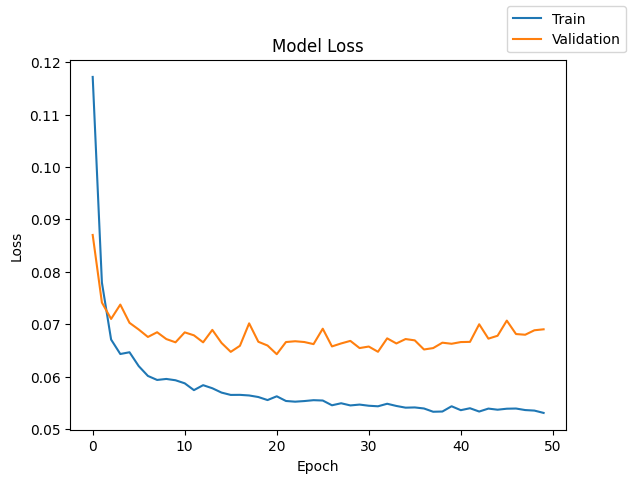

In [ ]:
plot(history1,'loss')

In [ ]:
model_1_train_perf = model_performance_classification(model1, X_train, y_train)
model_1_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.988625,0.911832,0.977152,0.941783


In [ ]:
model_1_val_perf = model_performance_classification(model1, X_val, y_val)
model_1_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9875,0.904347,0.973214,0.935731


In [ ]:
y_train_pred_1 = model1.predict(X_train)
y_val_pred_1 = model1.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
print("Classification Report - Train data Model_1",end="\n\n")
cr_train_model_1 = classification_report(y_train,y_train_pred_1>0.5)
print(cr_train_model_1)

Classification Report - Train data Model_1

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     15112
         1.0       0.96      0.83      0.89       888

    accuracy                           0.99     16000
   macro avg       0.98      0.91      0.94     16000
weighted avg       0.99      0.99      0.99     16000



In [ ]:
print("Classification Report - Train data Model_1",end="\n\n")
cr_train_model_1 = classification_report(y_val,y_val_pred_1>0.5)
print(cr_train_model_1)

Classification Report - Train data Model_1

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      3778
         1.0       0.96      0.81      0.88       222

    accuracy                           0.99      4000
   macro avg       0.97      0.90      0.94      4000
weighted avg       0.99      0.99      0.99      4000



### Model 1 Performance Summary

* Similar to Model 0, the model performs extremely well when detecting "no failure" scenarios across both train and validation sets.

* The model improves recall scores across both datasets but remains conservative, identifying only 0.81 of total failures (recall). However, when the model does predict a failure, it performs well at 0.97 (precision).

* The Model Loss graph shows an inconsistent decrease across train and validation sets, with the validation set normalizing at a higher loss level. This suggests the model may be overfitting.

* Adding momentum to the stochastic gradient optimizer appears to drive a slight improvement in recall score.

* A reasonable next step is to establish a baseline performance with a more adaptive and generally robust optimizer than basic SGD.

## Model 2

We built our third neural network model with the following changes:

The same architecture as the first two models (one hidden layer, 7 neurons).

* The model is trained for 50 epochs using a mini-batch gradient descent approach with a batch size of 40.
* Loss Function: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

Optimizer: We use the Adam optimizer as the optimizer to adjust the network's weights during training.

Metrics: The model is evaluated using the Recall metric.

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model2 = Sequential()

model2.add(Dense(7,activation="relu",input_dim=X_train.shape[1]))
model2.add(Dense(1,activation="sigmoid"))

In [ ]:
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │           287 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295 (1.15 KB)

 Trainable params: 295 (1.15 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam()
loss = 'binary_crossentropy'

model2.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [ ]:
epochs = 50
batch_size = 40

start = time.time()
history2 = model2.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.9557 - loss: 0.1641 - precision: 0.6967 - recall: 0.3570 - val_binary_accuracy: 0.9663 - val_loss: 0.1216 - val_precision: 0.8537 - val_recall: 0.4730
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9690 - loss: 0.1014 - precision: 0.8755 - recall: 0.5146 - val_binary_accuracy: 0.9728 - val_loss: 0.1010 - val_precision: 0.9185 - val_recall: 0.5586
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9736 - loss: 0.0900 - precision: 0.9206 - recall: 0.5743 - val_binary_accuracy: 0.9732 - val_loss: 0.0945 - val_precision: 0.9021 - val_recall: 0.5811
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9746 - loss: 0.0857 - precision: 0.9212 - recall: 0.5923 - val_binary_accuracy: 0.9740 - val_loss: 0.0913 - val_precision: 0.9041 - val_recall: 0.5946
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9760 - loss: 0.0830 - precision

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  66.02181887626648


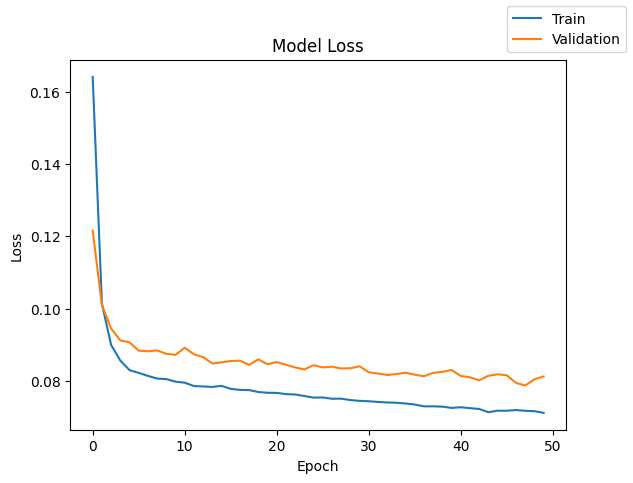

In [ ]:
plot(history2,'loss')

In [ ]:
model_2_train_perf = model_performance_classification(model2, X_train, y_train)
model_2_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.98375,0.864733,0.976533,0.912289


In [ ]:
model_2_val_perf = model_performance_classification(model2, X_val, y_val)
model_2_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9835,0.864071,0.974314,0.911048


In [ ]:
y_train_pred_2 = model2.predict(X_train)
y_val_pred_2 = model2.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
print("Classification Report - Train data Model_2",end="\n\n")
cr_train_model_2 = classification_report(y_train,y_train_pred_2>0.5)
print(cr_train_model_2)

Classification Report - Train data Model_2

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     15112
         1.0       0.97      0.73      0.83       888

    accuracy                           0.98     16000
   macro avg       0.98      0.86      0.91     16000
weighted avg       0.98      0.98      0.98     16000



In [ ]:
print("Classification Report - Train data Model_2",end="\n\n")
cr_train_model_2 = classification_report(y_val,y_val_pred_2>0.5)
print(cr_train_model_2)

Classification Report - Train data Model_2

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      3778
         1.0       0.96      0.73      0.83       222

    accuracy                           0.98      4000
   macro avg       0.97      0.86      0.91      4000
weighted avg       0.98      0.98      0.98      4000



### Model 2 Performance Summary
* Model 2 performs extremely well when detecting "no failure" scenarios across both train and validation sets.

* Adjusting optimizers (moving from Stochastic Gradient Descent to Adam) seems to have negatively impacted recall in comparison to models 0 and 1.

* The Model Loss graph shows improvement over Model 1, with the train and validation sets normalizing closer together.

* A reasonable next step is to investigate if increasing the model's depth allows it to capture more complex relationships in the data.

## Model 3
We built our third neural network model with the following changes:

* An updated foundational architecture (two hidden layers, 7 neurons each).
* The model is trained for 50 epochs using a mini-batch gradient descent approach with a batch size of 40.

Loss Function: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.
Optimizer: We use the Adam optimizer as the optimizer to adjust the network's weights during training.

Metrics: The model is evaluated using the Recall metric.

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model3 = Sequential()

model3.add(Dense(7,activation="relu",input_dim=X_train.shape[1]))
model3.add(Dense(7,activation="relu",input_dim=X_train.shape[1]))
model3.add(Dense(1,activation="sigmoid"))

In [ ]:
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │           287 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 351 (1.37 KB)

 Trainable params: 351 (1.37 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam()
loss = 'binary_crossentropy'

model3.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [ ]:
epochs = 50
batch_size = 40

start = time.time()
history3 = model3.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - binary_accuracy: 0.9166 - loss: 0.2316 - precision: 0.3474 - recall: 0.5732 - val_binary_accuracy: 0.9735 - val_loss: 0.1023 - val_precision: 0.8766 - val_recall: 0.6081
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9746 - loss: 0.0982 - precision: 0.8717 - recall: 0.6351 - val_binary_accuracy: 0.9808 - val_loss: 0.0853 - val_precision: 0.9050 - val_recall: 0.7297
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.9811 - loss: 0.0803 - precision: 0.9221 - recall: 0.7196 - val_binary_accuracy: 0.9847 - val_loss: 0.0762 - val_precision: 0.9259 - val_recall: 0.7883
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.9840 - loss: 0.0708 - precision: 0.9377 - recall: 0.7624 - val_binary_accuracy: 0.9865 - val_loss: 0.0691 - val_precision: 0.9667 - val_recall: 0.7838
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.9859 - loss: 0.0654 - precision

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  70.71718525886536


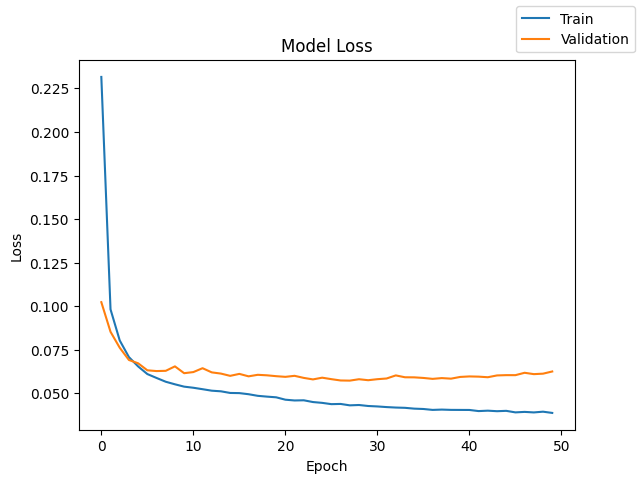

In [ ]:
plot(history3,'loss')

In [ ]:
model_3_train_perf = model_performance_classification(model3, X_train, y_train)
model_3_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.992437,0.938759,0.988252,0.962014


In [ ]:
model_3_val_perf = model_performance_classification(model3, X_val, y_val)
model_3_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.98925,0.915873,0.979436,0.945108


In [ ]:
y_train_pred_3 = model3.predict(X_train)
y_val_pred_3 = model3.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
print("Classification Report - Train data Model_3",end="\n\n")
cr_train_model_3 = classification_report(y_train,y_train_pred_3>0.5)
print(cr_train_model_3)

Classification Report - Train data Model_3

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     15112
         1.0       0.98      0.88      0.93       888

    accuracy                           0.99     16000
   macro avg       0.99      0.94      0.96     16000
weighted avg       0.99      0.99      0.99     16000



In [ ]:
print("Classification Report - Train data Model_3",end="\n\n")
cr_train_model_3 = classification_report(y_val,y_val_pred_3>0.5)
print(cr_train_model_3)

Classification Report - Train data Model_3

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      3778
         1.0       0.97      0.83      0.90       222

    accuracy                           0.99      4000
   macro avg       0.98      0.92      0.95      4000
weighted avg       0.99      0.99      0.99      4000



### Model 3 Performance Summary
* Model 3 continues previous trends, performing extremely well when detecting "no failure" scenarios across both train and validation sets.

* Adding a second hidden layer with 7 neurons each combined with the Adam optimizer produced the strongest recall score so far (0.88 train set, 0.83 validation set).

* Model 3's Loss graph returned the strongest results so far with loss continuing to shrink across train and validation sets. Both sets decreased across epochs and normalized fairly closer together. Without full convergence, the model may still be overfitting to some extent.

* A reasonable next step is to introduce regularization and mitigate potential overfitting, especially important as models become more complex.

## Model 4

We built our fourth neural network model with the following architecture:

* Two hidden layers, 7 neurons each, dropout layers after each hidden layer.
* The model is trained for 50 epochs using a mini-batch gradient descent approach with a batch size of 40.

Loss Function: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

Optimizer: We use the Adam optimizer as the optimizer to adjust the network's weights during training.

Metrics: The model is evaluated using the Recall metric.

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
from tensorflow.keras.layers import Dropout
model4 = Sequential()

model4.add(Dense(7,activation="relu",input_dim=X_train.shape[1]))
model4.add(Dropout(0.05))
model4.add(Dense(7,activation="relu",input_dim=X_train.shape[1]))
model4.add(Dropout(0.05))
model4.add(Dense(1,activation="sigmoid"))

In [ ]:
model4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │           287 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 351 (1.37 KB)

 Trainable params: 351 (1.37 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam()
loss = 'binary_crossentropy'

model4.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [ ]:
epochs = 50
batch_size = 40

start = time.time()
history4 = model4.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.9127 - loss: 0.2232 - precision: 0.2058 - recall: 0.2005 - val_binary_accuracy: 0.9643 - val_loss: 0.1214 - val_precision: 0.9647 - val_recall: 0.3694
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9649 - loss: 0.1280 - precision: 0.8260 - recall: 0.4651 - val_binary_accuracy: 0.9705 - val_loss: 0.1077 - val_precision: 0.9127 - val_recall: 0.5180
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.9718 - loss: 0.1094 - precision: 0.8670 - recall: 0.5800 - val_binary_accuracy: 0.9765 - val_loss: 0.0941 - val_precision: 0.9444 - val_recall: 0.6126
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.9752 - loss: 0.0963 - precision: 0.9058 - recall: 0.6171 - val_binary_accuracy: 0.9808 - val_loss: 0.0840 - val_precision: 0.9503 - val_recall: 0.6892
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.9776 - loss: 0.0865 - precision

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  72.89359641075134


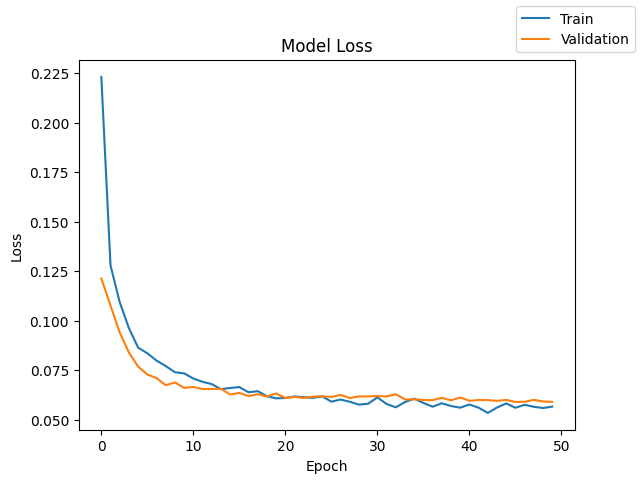

In [ ]:
plot(history4,'loss')

In [ ]:
model_4_train_perf = model_performance_classification(model4, X_train, y_train)
model_4_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.990313,0.917495,0.989221,0.950162


In [ ]:
model_4_val_perf = model_performance_classification(model4, X_val, y_val)
model_4_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.98975,0.916137,0.984564,0.94742


In [ ]:
y_train_pred_4 = model4.predict(X_train)
y_val_pred_4 = model4.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
print("Classification Report - Train data Model_4",end="\n\n")
cr_train_model_4 = classification_report(y_train,y_train_pred_4>0.5)
print(cr_train_model_4)

Classification Report - Train data Model_4

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     15112
         1.0       0.99      0.84      0.91       888

    accuracy                           0.99     16000
   macro avg       0.99      0.92      0.95     16000
weighted avg       0.99      0.99      0.99     16000



In [ ]:
print("Classification Report - Train data Model_4",end="\n\n")
cr_train_model_4 = classification_report(y_val,y_val_pred_4>0.5)
print(cr_train_model_4)

Classification Report - Train data Model_4

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      3778
         1.0       0.98      0.83      0.90       222

    accuracy                           0.99      4000
   macro avg       0.98      0.92      0.95      4000
weighted avg       0.99      0.99      0.99      4000



Model 4 Performance Summary

* Model 4 continues previous trends, performing extremely well when detecting "no failure" scenarios across both train and validation sets.

* Introducing a small dropout rate (0.05) appears to have a limited impact on the model effectiveness; recall scores of 0.84 (train) and 0.83 (val) run slightly lower than Model 3, which did not use dropout layers in any capacity.

* Model 4's Loss graph performed as desired, with both sets decreased across epochs and ultimately reaching convergence. This suggests model learning is stable and a good fit to the data.

* A reasonable next step is to introduce class weights, as we are dealing with an imbalance in class distribution. Class weights will allow the model to give proportionally more importance to the minority class (failure scenarios).

## Model 5

We built our fifth neural network model with the following architecture:

* Two hidden layers, with 14 neurons in the first layer and 7 neurons in the second layer, including dropout layers after each hidden layer.
* The model is trained for 50 epochs using a mini-batch gradient descent approach with a batch size of 40.
* Class weights are introduced to give more importance to the minority class (failure scenarios).

Loss Function: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

Optimizer: We use the Adam optimizer as the optimizer to adjust the network's weights during training.

Metrics: The model is evaluated using the Recall metric.

In [ ]:
# Calculate class weights for imbalanced dataset
cw = (y_train.shape[0]) / np.bincount(y_train.astype(int)) # Convert y_train to integers

# Create a dictionary mapping class indices to their respective class weights
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: np.float64(1.0587612493382743), 1: np.float64(18.01801801801802)}

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model5 = Sequential()

model5.add(Dense(14,activation="relu",input_dim=X_train.shape[1]))
model5.add(Dropout(0.05))
model5.add(Dense(7,activation="relu",input_dim=X_train.shape[1]))
model5.add(Dropout(0.05))
model5.add(Dense(1,activation="sigmoid"))

In [ ]:
model5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687 (2.68 KB)

 Trainable params: 687 (2.68 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam()
loss = 'binary_crossentropy'

model5.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [ ]:
start = time.time()
history5 = model5.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.7459 - loss: 1.0837 - precision: 0.1478 - recall: 0.7511 - val_binary_accuracy: 0.8815 - val_loss: 0.2892 - val_precision: 0.2955 - val_recall: 0.8198
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.8782 - loss: 0.7165 - precision: 0.2932 - recall: 0.8468 - val_binary_accuracy: 0.9000 - val_loss: 0.2949 - val_precision: 0.3422 - val_recall: 0.8694
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9134 - loss: 0.5822 - precision: 0.3791 - recall: 0.8773 - val_binary_accuracy: 0.9557 - val_loss: 0.2017 - val_precision: 0.5668 - val_recall: 0.8604
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9436 - loss: 0.5171 - precision: 0.4953 - recall: 0.8874 - val_binary_accuracy: 0.9600 - val_loss: 0.1863 - val_precision: 0.5945 - val_recall: 0.8784
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9488 - loss: 0.4814 - precision

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  74.58119750022888


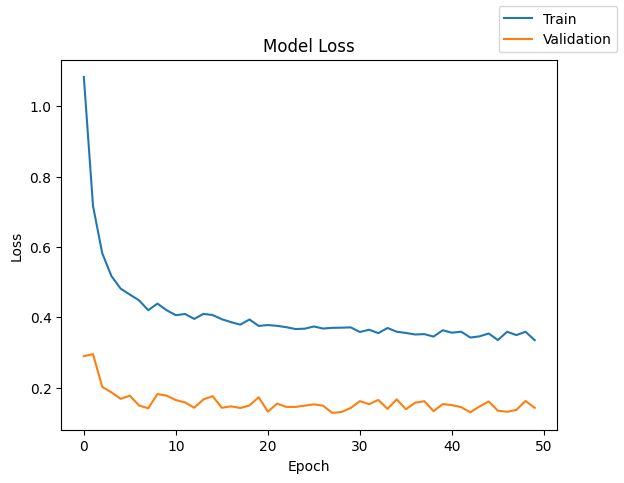

In [ ]:
plot(history5,'loss')

In [ ]:
model_5_train_perf = model_performance_classification(model5, X_train, y_train)
model_5_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.985125,0.950787,0.914931,0.932005


In [ ]:
model_5_val_perf = model_performance_classification(model5, X_val, y_val)
model_5_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.98075,0.932572,0.894364,0.912448


In [ ]:
y_train_pred_5 = model5.predict(X_train)
y_val_pred_5 = model5.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
print("Classification Report - Train data Model_5",end="\n\n")
cr_train_model_5 = classification_report(y_train,y_train_pred_5>0.5)
print(cr_train_model_5)

Classification Report - Train data Model_5

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     15112
         1.0       0.84      0.91      0.87       888

    accuracy                           0.99     16000
   macro avg       0.91      0.95      0.93     16000
weighted avg       0.99      0.99      0.99     16000



In [ ]:
print("Classification Report - Val data Model_5",end="\n\n")
cr_val_model_5 = classification_report(y_val,y_val_pred_5>0.5)
print(cr_train_model_5)

Classification Report - Val data Model_5

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     15112
         1.0       0.84      0.91      0.87       888

    accuracy                           0.99     16000
   macro avg       0.91      0.95      0.93     16000
weighted avg       0.99      0.99      0.99     16000



###Model 5 Performance Summary

* Model 5 continues previous trends, performing extremely well when detecting "no failure" scenarios across both train and validation sets.

* Introducing class weights and increasing the number of neurons in the first hidden layer positively impacted recall, with the highest train (0.91) and validation (0.91) scores to date. While precison fell to its lowest level, an 0.84 precision across both data sets is still good, creating an acceptable tradeoff.

* Model 5's Loss graph performed as desired, with both sets decreasing across epochs. While the train and validation sets do not formally converage, consistent decrease and movement closer together suggests the model learning is stable and a good fit to the data.

* A reasonable next step is to explore adding more neurons, introducing new hidden layers, and experimenting with dropout rate. Model 5's performance suggets a model combination using higher neurons, dropout rate, and class weights will create the strongest model.

## Model 6

We built our sixth neural network model with the following architecture:

* Three hidden layers: 28 neurons in the first hidden layer, 28 neurons in the second hidden layer, 14 neurons in the third hidden layer. 0.1 Dropout rate was used after each hidden layer.
* The model is trained for 50 epochs using a mini-batch gradient descent approach with a batch size of 40.
* Class weights are introduced to give more importance to the minority class (failure scenarios).

Loss Function: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

Optimizer: We use the Adam optimizer as the optimizer to adjust the network's weights during training.

Metrics: The model is evaluated using the Recall metric.

In [ ]:
# Calculate class weights for imbalanced dataset
cw = (y_train.shape[0]) / np.bincount(y_train.astype(int)) # Convert y_train to integers

# Create a dictionary mapping class indices to their respective class weights
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: np.float64(1.0587612493382743), 1: np.float64(18.01801801801802)}

In [ ]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
#Initializing the neural network
model6 = Sequential()

model6.add(Dense(28,activation="relu",input_dim=X_train.shape[1]))
model6.add(Dropout(0.1))
model6.add(Dense(28,activation="relu",input_dim=X_train.shape[1]))
model6.add(Dropout(0.1))
model6.add(Dense(14,activation="relu",input_dim=X_train.shape[1]))
model6.add(Dropout(0.1))
model6.add(Dense(1,activation="sigmoid"))

In [ ]:
model6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 28)             │         1,148 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 28)             │           812 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │           406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,381 (9.30 KB)

 Trainable params: 2,381 (9.30 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam()
loss = 'binary_crossentropy'

model6.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [ ]:
start = time.time()
history6 = model6.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.8256 - loss: 0.8230 - precision: 0.2191 - recall: 0.8356 - val_binary_accuracy: 0.9503 - val_loss: 0.2147 - val_precision: 0.5317 - val_recall: 0.8694
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9257 - loss: 0.5602 - precision: 0.4191 - recall: 0.8784 - val_binary_accuracy: 0.9700 - val_loss: 0.1595 - val_precision: 0.6809 - val_recall: 0.8649
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9524 - loss: 0.5012 - precision: 0.5438 - recall: 0.8885 - val_binary_accuracy: 0.9697 - val_loss: 0.1721 - val_precision: 0.6735 - val_recall: 0.8829
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9609 - loss: 0.4567 - precision: 0.5997 - recall: 0.8908 - val_binary_accuracy: 0.9793 - val_loss: 0.1585 - val_precision: 0.7725 - val_recall: 0.8874
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.9686 - loss: 0.4296 - precision

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  78.68196749687195


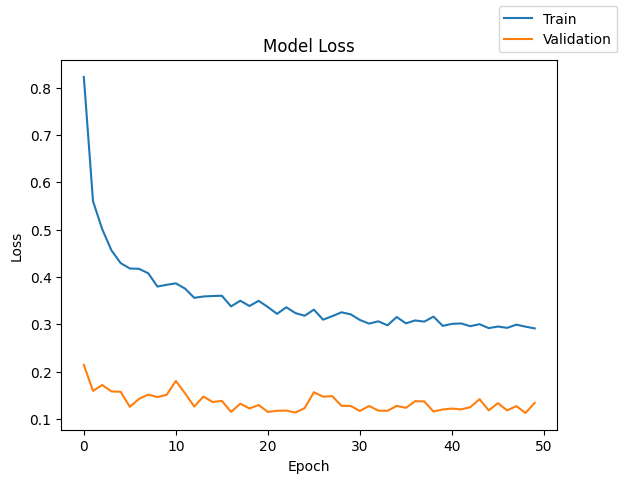

In [ ]:
plot(history6,'loss')

In [ ]:
model_6_train_perf = model_performance_classification(model6, X_train, y_train)
model_6_train_perf

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.990938,0.961284,0.953129,0.957165


In [ ]:
model_6_val_perf = model_performance_classification(model6, X_val, y_val)
model_6_val_perf

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9875,0.942505,0.938786,0.940637


In [ ]:
y_train_pred_6 = model6.predict(X_train)
y_val_pred_6 = model6.predict(X_val)

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
print("Classification Report - Train data Model_6",end="\n\n")
cr_train_model_6 = classification_report(y_train,y_train_pred_6>0.5)
print(cr_train_model_6)

Classification Report - Train data Model_6

              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00     15112
         1.0       0.91      0.93      0.92       888

    accuracy                           0.99     16000
   macro avg       0.95      0.96      0.96     16000
weighted avg       0.99      0.99      0.99     16000



In [ ]:
print("Classification Report - Val data Model_6",end="\n\n")
cr_val_model_6 = classification_report(y_val,y_val_pred_6>0.5)
print(cr_train_model_6)

Classification Report - Val data Model_6

              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00     15112
         1.0       0.91      0.93      0.92       888

    accuracy                           0.99     16000
   macro avg       0.95      0.96      0.96     16000
weighted avg       0.99      0.99      0.99     16000



Model 6 Performance Summary

* Model 6 continues previous trends, performing extremely well when detecting "no failure" scenarios across both train and validation sets.

* Introducing an additional hidden layer and increasing the number of neurons in each hidden layer positively impacted all performance metrics. Recall increased slightly (0.93) while precision moved back above 0.90.

* With recall and precision both functioning above 0.90, we have a well performing model.

* Model 6's Loss graph performed as desired, with both sets decreasing across epochs. While the train and validation sets do not formally converage, consistent decrease and movement closer together suggests the model learning is stable and a good fit to the data.

* Next we will evaluate performance across all six models.

# **Model Performance Comparison and Final Model Selection**

Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_0_train_perf.T,
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
        model_5_train_perf.T,
        model_6_train_perf.T

    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Model 0",
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
    "Model 5",
    "Model 6"
]
print("Training set performance comparison:")
models_train_comp_df

Training set performance comparison:


,Model 0,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6
Accuracy,0.988688,0.988625,0.983750,0.989250,0.990313,0.985125,0.990938
Recall,0.912395,0.911832,0.864733,0.915873,0.917495,0.950787,0.961284
Precision,0.977207,0.977152,0.976533,0.979436,0.989221,0.914931,0.953129
F1 Score,0.942136,0.941783,0.912289,0.945108,0.950162,0.932005,0.957165


In [ ]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [
        model_0_val_perf.T,
        model_1_val_perf.T,
        model_2_val_perf.T,
        model_3_val_perf.T,
        model_4_val_perf.T,
        model_5_val_perf.T,
        model_6_val_perf.T

    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Model 0",
    "Model 1",
    "Model 2",
    "Model 3",
    "Model 4",
    "Model 5",
    "Model 6"
]
print("Validation set performance comparison:")
models_val_comp_df

Validation set performance comparison:


,Model 0,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6
Accuracy,0.988000,0.987500,0.983500,0.989250,0.989750,0.980750,0.987500
Recall,0.910971,0.904347,0.864071,0.915873,0.916137,0.932572,0.942505
Precision,0.971442,0.973214,0.974314,0.979436,0.984564,0.894364,0.938786
F1 Score,0.938865,0.935731,0.911048,0.945108,0.947420,0.912448,0.940637


### Selecting the Best Performing Model

Selected Model: Model 6 (Adam, Three Hidden Layers, Class Weights, Dropout)

Reasoning: In Predictive Maintenance, Recall is the most critical metric.
The financial cost of failing to detect a machine that needs repair leading to a replacement (a False Negative) is far greater than the inconvenience of inspecting a machine that does not need repair (a False Positive).

False Negative (Failures that are not detected):
ReneWind loses money and customer trust. This is a high-cost error and must be minimized as much as possible.

False Positive (Detections where there is no failure):
A legitimate customer may be temporarily blocked from using their machine. This is a comparatively low-cost error.

Model 6 achieved the highest validation Recall among all candidates:

It captures almost all true failures, making it the most suitable choice for this high‑risk, cost‑sensitive application.

In [ ]:
best_model = model6


Now, let's check the performance of the final model on the test set.

In [ ]:
# Test set performance for the best model
best_model_test_perf = model_performance_classification(best_model,X_test,y_test)
best_model_test_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9856,0.932355,0.932355,0.932355


In [ ]:
y_test_pred_best = best_model.predict(X_test)

cr_test_best_model = classification_report(y_test, y_test_pred_best>0.5) # Check the classification report of best model on test data.
print(cr_test_best_model)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      4718
         1.0       0.87      0.87      0.87       282

    accuracy                           0.99      5000
   macro avg       0.93      0.93      0.93      5000
weighted avg       0.99      0.99      0.99      5000



# **Actionable Insights and Recommendations**

High Recall
* The final model achieved a strong validation Recall, meaning it successfully identifies the vast majority of failure scenarios. This is the most critical metric for predictive maintenance because missing a failure (False Negative) leads to replacement costs. High Recall often comes with a trade-off in Precision (more false positives). In this case, however, Precision also scored well.

Overfitting Gap
* Model 6 failed to reach previous recall highs from training and validation datasets (0.94) on the test set (0.87). This gap suggests the model is slightly overfitting on training and validation data.

Further ways to improve the model
* Exploratory Data Analysis uncovered 12 features with a correlation above 80%. The interconnectedness of these features may make it challenging for the model to maximize learning and fully understand the relationships between data. For best results, removing several features with extremely high correlation will position the model to learn more effectively and ultimately improve model performance.